# Βαθιά Μάθηση (ΕΠ22στ) - Σύγχρονες Μέθοδοι Βαθιάς Μάθησης
## Συγκριτική Μελέτη σε Δορυφορικά Δεδομένα (EuroSAT)

**Ατομική Εργασία**

# 0 - Προετοιμασία και Σύνολο Δεδομένων

## Εισαγωγή Βιβλιοθηκών

In [1]:
import os
import numpy as np
import matplotlib.pyplot as plt
from PIL import Image
import torch
import torch.nn as nn
import torchvision
from torchvision import datasets, transforms
from torch.utils.data import DataLoader, Subset, Dataset
from collections import Counter
import random

# Set random seeds for reproducibility
random.seed(42)
np.random.seed(42)
torch.manual_seed(42)
if torch.cuda.is_available():
    torch.cuda.manual_seed(42)

device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print(f"Device: {device}")

Device: cuda


## Task 0.1 - Φόρτωση EuroSAT Dataset

In [2]:
# SSL fix for Windows download issues (force unverified if needed)
import ssl, certifi, os
os.environ["SSL_CERT_FILE"] = certifi.where()
os.environ["REQUESTS_CA_BUNDLE"] = certifi.where()
# Force unverified context to bypass local certificate issues (less secure)
ssl._create_default_https_context = ssl._create_unverified_context
print("SSL set to unverified context. Proceeding to download EuroSAT...")

SSL set to unverified context. Proceeding to download EuroSAT...


In [3]:
# Download and load EuroSAT dataset
data_dir = './data'

# Basic transform for loading (no augmentations yet)
basic_transform = transforms.Compose([
    transforms.ToTensor(),
])



# Load full dataset
full_dataset = datasets.EuroSAT(root=data_dir, download=True, transform=basic_transform)

# Get basic information
num_samples = len(full_dataset)
num_classes = len(full_dataset.classes)
class_names = full_dataset.classes

# Get image dimensions from first image
sample_image, _ = full_dataset[0]
image_shape = sample_image.shape

print("=" * 50)
print("EuroSAT Dataset Information")
print("=" * 50)
print(f"Total samples: {num_samples}")
print(f"Number of classes: {num_classes}")
print(f"Image dimensions: {image_shape[1]}x{image_shape[2]} pixels")
print(f"Number of channels: {image_shape[0]} (RGB)")
print(f"\nClass names:")
for i, class_name in enumerate(class_names):
    print(f"  {i}: {class_name}")

100%|██████████| 94.3M/94.3M [00:01<00:00, 47.5MB/s]


EuroSAT Dataset Information
Total samples: 27000
Number of classes: 10
Image dimensions: 64x64 pixels
Number of channels: 3 (RGB)

Class names:
  0: AnnualCrop
  1: Forest
  2: HerbaceousVegetation
  3: Highway
  4: Industrial
  5: Pasture
  6: PermanentCrop
  7: Residential
  8: River
  9: SeaLake


## Task 0.2 - Δημιουργία Data Splits

In [4]:
# Get all indices and their labels
all_indices = list(range(len(full_dataset)))
all_labels = [full_dataset[i][1] for i in all_indices]

# Group indices by class
class_indices = {i: [] for i in range(num_classes)}
for idx, label in enumerate(all_labels):
    class_indices[label].append(idx)

# Shuffle indices within each class
for class_id in class_indices:
    random.shuffle(class_indices[class_id])

# Create splits for each class
train_full_indices = []
train_10shot_indices = []
train_5shot_indices = []
val_indices = []
test_indices = []

for class_id, indices in class_indices.items():
    n_class = len(indices)
    
    # Calculate split sizes (70% train, 15% val, 15% test)
    n_train = int(0.70 * n_class)
    n_val = int(0.15 * n_class)
    n_test = n_class - n_train - n_val
    
    # Split indices
    train_full_indices.extend(indices[:n_train])
    val_indices.extend(indices[n_train:n_train + n_val])
    test_indices.extend(indices[n_train + n_val:])
    
    # Few-shot splits (from train set)
    train_10shot_indices.extend(indices[:10])
    train_5shot_indices.extend(indices[:5])

# Shuffle the combined splits
random.shuffle(train_full_indices)
random.shuffle(val_indices)
random.shuffle(test_indices)
random.shuffle(train_10shot_indices)
random.shuffle(train_5shot_indices)

print("=" * 50)
print("Data Splits Created")
print("=" * 50)
print(f"Train Full:   {len(train_full_indices)} samples")
print(f"Train 10-shot: {len(train_10shot_indices)} samples (10 per class)")
print(f"Train 5-shot:  {len(train_5shot_indices)} samples (5 per class)")
print(f"Validation:    {len(val_indices)} samples")
print(f"Test:          {len(test_indices)} samples")
print(f"\nTotal: {len(train_full_indices) + len(val_indices) + len(test_indices)} samples")

Data Splits Created
Train Full:   18900 samples
Train 10-shot: 100 samples (10 per class)
Train 5-shot:  50 samples (5 per class)
Validation:    4050 samples
Test:          4050 samples

Total: 27000 samples


In [5]:
# Print per-class distribution
print("\n" + "=" * 50)
print("Per-Class Distribution")
print("=" * 50)
print(f"{'Class':<20} {'Train Full':<12} {'Val':<8} {'Test':<8} {'Total':<8}")
print("-" * 50)

for class_id, class_name in enumerate(class_names):
    n_train = sum(1 for idx in train_full_indices if all_labels[idx] == class_id)
    n_val = sum(1 for idx in val_indices if all_labels[idx] == class_id)
    n_test = sum(1 for idx in test_indices if all_labels[idx] == class_id)
    n_total = len(class_indices[class_id])
    print(f"{class_name:<20} {n_train:<12} {n_val:<8} {n_test:<8} {n_total:<8}")


Per-Class Distribution
Class                Train Full   Val      Test     Total   
--------------------------------------------------
AnnualCrop           2100         450      450      3000    
Forest               2100         450      450      3000    
HerbaceousVegetation 2100         450      450      3000    
Highway              1750         375      375      2500    
Industrial           1750         375      375      2500    
Pasture              1400         300      300      2000    
PermanentCrop        1750         375      375      2500    
Residential          2100         450      450      3000    
River                1750         375      375      2500    
SeaLake              2100         450      450      3000    


## Task 0.3 - Preprocessing και Augmentations

In [6]:
from torchvision import transforms

# Define augmentations for training (minimal, clean baseline)
train_transform = transforms.Compose([
    transforms.RandomHorizontalFlip(p=0.5),
    transforms.RandomVerticalFlip(p=0.5),
    transforms.ColorJitter(brightness=0.2, contrast=0.2, saturation=0.2),
    transforms.ToTensor(),
    transforms.Normalize(mean=[0.485, 0.456, 0.406], std=[0.229, 0.224, 0.225])  # ImageNet stats
])

# Define transforms for validation/test (no augmentation)
val_test_transform = transforms.Compose([
    transforms.ToTensor(),
    transforms.Normalize(mean=[0.485, 0.456, 0.406], std=[0.229, 0.224, 0.225])
])

print("Augmentations defined:")

Augmentations defined:


In [7]:
# Create datasets with appropriate transforms
train_dataset_full = datasets.EuroSAT(root=data_dir, download=False, transform=train_transform)
train_dataset_10shot = datasets.EuroSAT(root=data_dir, download=False, transform=train_transform)
train_dataset_5shot = datasets.EuroSAT(root=data_dir, download=False, transform=train_transform)
val_dataset = datasets.EuroSAT(root=data_dir, download=False, transform=val_test_transform)
test_dataset = datasets.EuroSAT(root=data_dir, download=False, transform=val_test_transform)

# Create subset datasets
train_full = Subset(train_dataset_full, train_full_indices)
train_10shot = Subset(train_dataset_10shot, train_10shot_indices)
train_5shot = Subset(train_dataset_5shot, train_5shot_indices)
val_set = Subset(val_dataset, val_indices)
test_set = Subset(test_dataset, test_indices)

print("Datasets created successfully!")

Datasets created successfully!


## Task 0.4 - Οπτικοποιήσεις

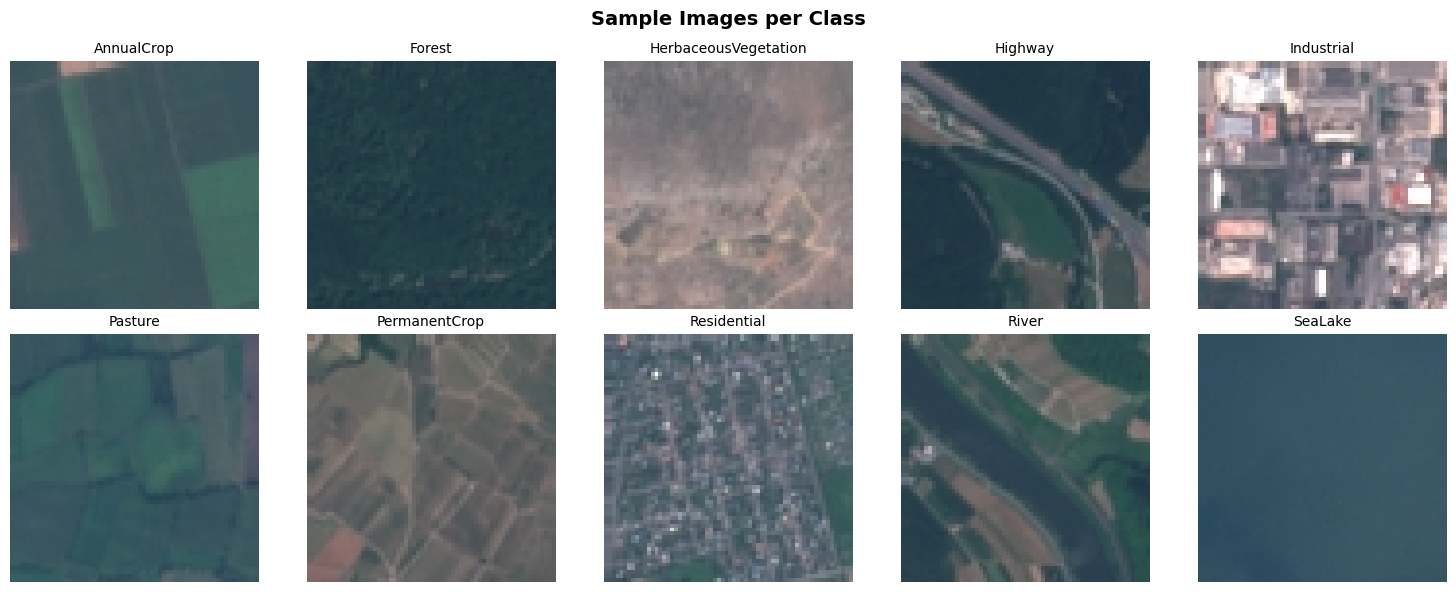

In [8]:
# Visualization 1: Sample images per class
fig, axes = plt.subplots(2, 5, figsize=(15, 6))
axes = axes.flatten()

# Load dataset without normalization for visualization
viz_dataset = datasets.EuroSAT(root=data_dir, download=False, transform=transforms.ToTensor())

for class_id, class_name in enumerate(class_names):
    # Get first sample of this class from train set
    class_sample_idx = class_indices[class_id][0]
    img, label = viz_dataset[class_sample_idx]
    
    # Convert to numpy and transpose for plotting
    img_np = img.permute(1, 2, 0).numpy()
    
    axes[class_id].imshow(img_np)
    axes[class_id].set_title(class_name, fontsize=10)
    axes[class_id].axis('off')

plt.suptitle('Sample Images per Class', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.show()

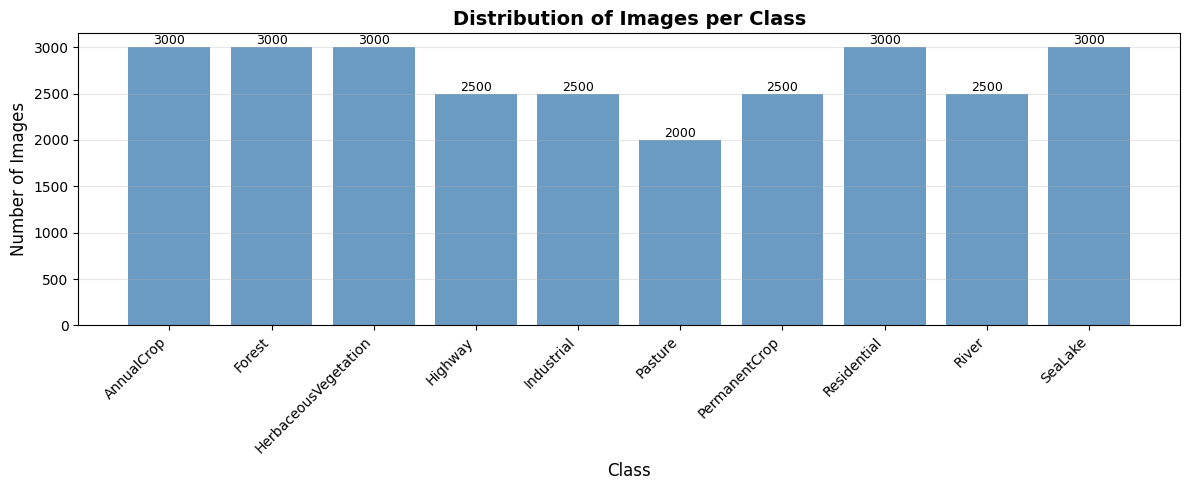

In [9]:
# Visualization 2: Distribution of images per class
class_counts = [len(class_indices[i]) for i in range(num_classes)]

plt.figure(figsize=(12, 5))
bars = plt.bar(range(num_classes), class_counts, color='steelblue', alpha=0.8)
plt.xlabel('Class', fontsize=12)
plt.ylabel('Number of Images', fontsize=12)
plt.title('Distribution of Images per Class', fontsize=14, fontweight='bold')
plt.xticks(range(num_classes), class_names, rotation=45, ha='right')
plt.grid(axis='y', alpha=0.3)

# Add count labels on bars
for i, bar in enumerate(bars):
    height = bar.get_height()
    plt.text(bar.get_x() + bar.get_width()/2., height,
             f'{int(height)}', ha='center', va='bottom', fontsize=9)

plt.tight_layout()
plt.show()

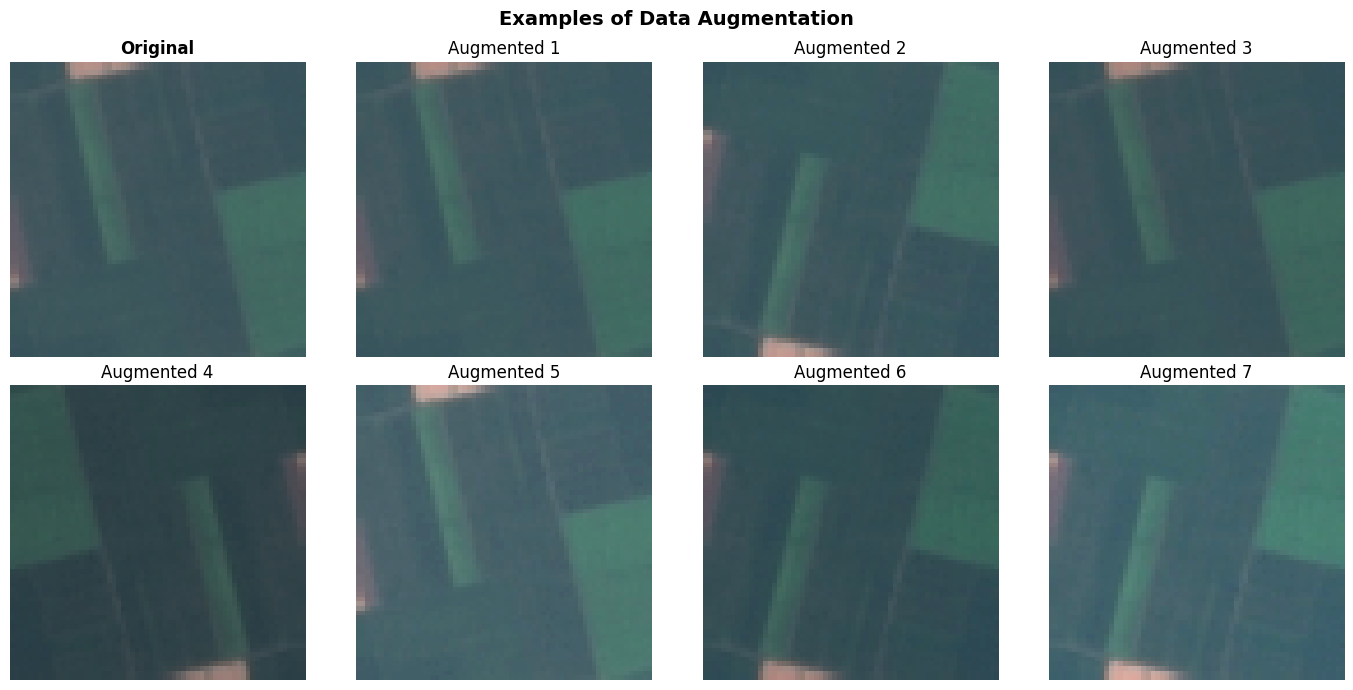

In [10]:
# Visualization 3: Examples of augmented images
# Helper function to denormalize for visualization
def denormalize(tensor):
    mean = torch.tensor([0.485, 0.456, 0.406]).view(3, 1, 1)
    std = torch.tensor([0.229, 0.224, 0.225]).view(3, 1, 1)
    return tensor * std + mean

# Get one sample
sample_idx = class_indices[0][0]
original_img, _ = viz_dataset[sample_idx]

# Create augmented versions
fig, axes = plt.subplots(2, 4, figsize=(14, 7))

# Original
axes[0, 0].imshow(original_img.permute(1, 2, 0).numpy())
axes[0, 0].set_title('Original', fontweight='bold')
axes[0, 0].axis('off')

# Apply train transforms multiple times to see different augmentations
augmentation_names = [
    'Augmented 1', 'Augmented 2', 'Augmented 3',
    'Augmented 4', 'Augmented 5', 'Augmented 6', 'Augmented 7'
]

for idx, ax in enumerate(axes.flatten()[1:]):
    # Get augmented image
    aug_img, _ = train_dataset_full[sample_idx]
    aug_img = denormalize(aug_img)
    aug_img = torch.clamp(aug_img, 0, 1)
    
    ax.imshow(aug_img.permute(1, 2, 0).numpy())
    ax.set_title(augmentation_names[idx])
    ax.axis('off')

plt.suptitle('Examples of Data Augmentation', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.show()

## Q0.1 - Περιγραφή Splits και Data Leakage

**Περιγραφή των Splits:**

Δημιουργήσαμε πέντε διαφορετικά splits από το σύνολο δεδομένων EuroSAT:

1. **Train Full (70%)**: Περιέχει το 70% των δεδομένων από κάθε κλάση για πλήρη εκπαίδευση
2. **Train 10-shot**: Περιέχει ακριβώς 10 δείγματα ανά κλάση (100 δείγματα συνολικά)
3. **Train 5-shot**: Περιέχει ακριβώς 5 δείγματα ανά κλάση (50 δείγματα συνολικά)
4. **Validation (15%)**: Περιέχει το 15% των δεδομένων από κάθε κλάση
5. **Test (15%)**: Περιέχει το 15% των δεδομένων από κάθε κλάση

**Διασφάλιση κατά του Data Leakage:**

Για να αποφύγουμε data leakage μεταξύ των συνόλων:

1. **Χωρισμός ανά κλάση**: Ομαδοποιήσαμε τα δεδομένα ανά κλάση πριν τον χωρισμό
2. **Αποκλειστικά subsets**: Κάθε εικόνα ανήκει σε **ένα μόνο** split (train, validation ή test)
3. **Σταθερό random seed**: Χρησιμοποιήσαμε σταθερό seed (42) για αναπαραγωγιμότητα
4. **Few-shot από train**: Τα 5-shot και 10-shot splits προέρχονται από το train set, όχι από validation/test
5. **Καμία επικάλυψη**: Οι δείκτες (indices) των τριών κύριων splits (train/val/test) είναι πλήρως διακριτοί

Η σειρά χωρισμού ήταν: πρώτα τα train samples (70%), μετά validation (15%) και τέλος test (15%), εξασφαλίζοντας μηδενική επικάλυψη.

## Q0.2 - Επιλογή και Αιτιολόγηση Augmentations

**Augmentations που χρησιμοποιήθηκαν:**

1. **Color Jitter (brightness, contrast, saturation)**:
   - Προσομοιώνει διαφορετικές συνθήκες φωτισμού και ατμοσφαιρικές συνθήκες
   - Διαφορετικές εποχές του χρόνου ή ώρες της ημέρας
   - Χρησιμοποιούμε μικρές τιμές (0.2) για να μην αλλοιώσουμε τα χρώματα υπερβολικά

2. **Normalization (ImageNet statistics)**:
   - Χρησιμοποιούμε ImageNet statistics για συμβατότητα με pretrained μοντέλα
   - Βοηθά στη σταθερότητα της εκπαίδευσης

**Γιατί αποφεύγουμε ορισμένες augmentations:**

- **Random Crop**: Οι εικόνες είναι μικρές (64x64) και ένα crop θα έχανε σημαντική πληροφορία
- **Random Flips/Rotation**: Αν και θεωρητικά ρεαλιστικά για satellite imagery, τα τυχαία geometric transforms προσθέτουν variability χωρίς εγγυημένη βελτίωση στην απόδοση του baseline
- **Perspective Transform**: Οι δορυφορικές εικόνες έχουν top-down view, άρα δεν είναι ρεαλιστική η αλλαγή προοπτικής
- **Elastic Deformation**: Οι δομές γης δεν παραμορφώνονται, θα ήταν μη ρεαλιστικό

Οι επιλεγμένες augmentations (μόνο ColorJitter) είναι **ελαφριές και ρεαλιστικές**, προσομοιώνουν διαφορετικές συνθήκες φωτισμού χωρίς να αλλάζουν τη γεωμετρία, παρέχοντας καθαρό baseline για σύγκριση.

# 1 – Baseline και Transfer Learning

## Task 1.1 – Baseline CNN από το μηδέν

In [11]:
# DataLoaders for baseline CNN
from torch.utils.data import DataLoader

batch_size = 32

train_loader = DataLoader(train_full, batch_size=batch_size, shuffle=True, num_workers=2, pin_memory=torch.cuda.is_available())
val_loader = DataLoader(val_set, batch_size=batch_size, shuffle=False, num_workers=2, pin_memory=torch.cuda.is_available())
test_loader = DataLoader(test_set, batch_size=batch_size, shuffle=False, num_workers=2, pin_memory=torch.cuda.is_available())

print(f"Train batches: {len(train_loader)}, Val batches: {len(val_loader)}, Test batches: {len(test_loader)}")

Train batches: 591, Val batches: 127, Test batches: 127


In [12]:
# Baseline CNN (3 conv layers)
import time

class BaselineCNN(nn.Module):
    def __init__(self, num_classes=10):
        super().__init__()
        self.features = nn.Sequential(
            nn.Conv2d(3, 32, kernel_size=3, padding=1),
            nn.BatchNorm2d(32),
            nn.ReLU(inplace=True),
            nn.MaxPool2d(2),  # 32x32

            nn.Conv2d(32, 64, kernel_size=3, padding=1),
            nn.BatchNorm2d(64),
            nn.ReLU(inplace=True),
            nn.MaxPool2d(2),  # 16x16

            nn.Conv2d(64, 128, kernel_size=3, padding=1),
            nn.BatchNorm2d(128),
            nn.ReLU(inplace=True),
            nn.MaxPool2d(2),  # 8x8
        )
        self.classifier = nn.Sequential(
            nn.Flatten(),
            nn.Linear(128 * 8 * 8, 256),
            nn.ReLU(inplace=True),
            nn.Dropout(0.5),
            nn.Linear(256, num_classes)
        )

    def forward(self, x):
        x = self.features(x)
        return self.classifier(x)


def accuracy(loader, model):
    model.eval()
    correct, total = 0, 0
    with torch.no_grad():
        for xb, yb in loader:
            xb, yb = xb.to(device), yb.to(device)
            preds = model(xb).argmax(dim=1)
            correct += (preds == yb).sum().item()
            total += yb.size(0)
    return correct / total


def train_baseline(model, train_loader, val_loader, epochs=10, lr=1e-3):
    model.to(device)
    criterion = nn.CrossEntropyLoss()
    optimizer = torch.optim.Adam(model.parameters(), lr=lr)
    history = {"train_loss": [], "val_loss": [], "train_acc": [], "val_acc": []}

    for epoch in range(1, epochs + 1):
        model.train()
        running_loss = 0.0
        train_correct, train_total = 0, 0

        for xb, yb in train_loader:
            xb, yb = xb.to(device), yb.to(device)
            optimizer.zero_grad()
            logits = model(xb)
            loss = criterion(logits, yb)
            loss.backward()
            optimizer.step()

            running_loss += loss.item() * xb.size(0)
            preds = logits.argmax(dim=1)
            train_correct += (preds == yb).sum().item()
            train_total += yb.size(0)

        epoch_train_loss = running_loss / len(train_loader.dataset)
        epoch_train_acc = train_correct / train_total if train_total > 0 else 0.0

        # Validation (single pass)
        model.eval()
        val_loss = 0.0
        val_correct, val_total = 0, 0

        with torch.no_grad():
            for xb, yb in val_loader:
                xb, yb = xb.to(device), yb.to(device)
                logits = model(xb)
                loss = criterion(logits, yb)

                val_loss += loss.item() * xb.size(0)
                preds = logits.argmax(dim=1)
                val_correct += (preds == yb).sum().item()
                val_total += yb.size(0)

        epoch_val_loss = val_loss / len(val_loader.dataset)
        val_acc = val_correct / val_total

        history["train_loss"].append(epoch_train_loss)
        history["val_loss"].append(epoch_val_loss)
        history["train_acc"].append(epoch_train_acc)
        history["val_acc"].append(val_acc)

        print(
            f"Epoch {epoch:02d}: "
            f"train_loss={epoch_train_loss:.4f} "
            f"val_loss={epoch_val_loss:.4f} "
            f"train_acc={epoch_train_acc*100:.2f}% "
            f"val_acc={val_acc*100:.2f}%"
        )

    return history

In [31]:
# Train baseline
start_time = time.time()
model = BaselineCNN(num_classes=num_classes)
history = train_baseline(model, train_loader, val_loader, epochs=10, lr=1e-3)
train_time = time.time() - start_time

val_acc = history["val_acc"][-1]
test_acc = accuracy(test_loader, model)
param_count = sum(p.numel() for p in model.parameters())

print("=" * 50)
print(f"Validation accuracy: {val_acc*100:.2f}%")
print(f"Test accuracy: {test_acc*100:.2f}%")
print(f"Trainable parameters: {param_count:,}")
print(f"Training time (s): {train_time:.1f}")

Epoch 01: train_loss=1.4735 val_loss=0.8855 train_acc=46.43% val_acc=69.19%
Epoch 02: train_loss=1.1469 val_loss=0.6956 train_acc=58.00% val_acc=74.44%
Epoch 03: train_loss=1.0391 val_loss=0.6803 train_acc=62.62% val_acc=73.95%
Epoch 04: train_loss=0.9493 val_loss=0.6754 train_acc=65.89% val_acc=76.96%
Epoch 05: train_loss=0.8597 val_loss=0.5742 train_acc=69.64% val_acc=78.00%
Epoch 06: train_loss=0.8115 val_loss=0.5078 train_acc=71.93% val_acc=82.30%
Epoch 07: train_loss=0.7452 val_loss=0.5286 train_acc=74.34% val_acc=80.99%
Epoch 08: train_loss=0.7029 val_loss=0.4876 train_acc=76.11% val_acc=83.19%
Epoch 09: train_loss=0.6631 val_loss=0.3868 train_acc=77.62% val_acc=86.17%
Epoch 10: train_loss=0.6169 val_loss=0.4268 train_acc=78.86% val_acc=84.94%
Validation accuracy: 84.94%
Test accuracy: 84.74%
Trainable parameters: 2,193,674
Training time (s): 128.3


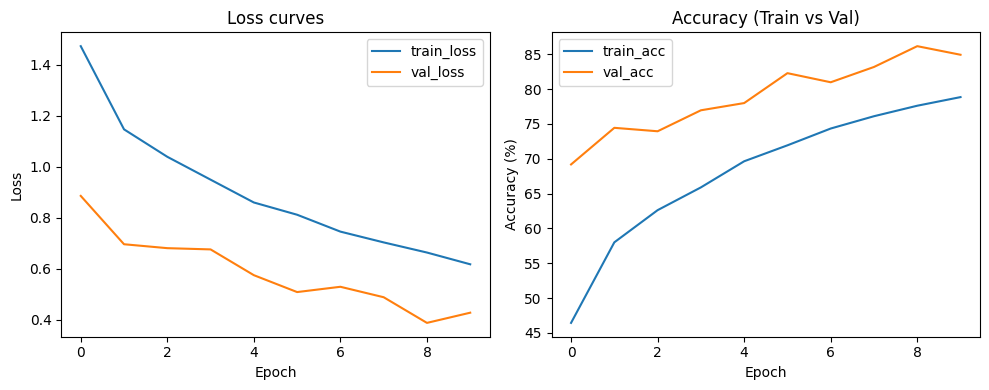

In [32]:
# Plot training curves
plt.figure(figsize=(10,4))
plt.subplot(1,2,1)
plt.plot(history["train_loss"], label="train_loss")
plt.plot(history["val_loss"], label="val_loss")
plt.xlabel("Epoch")
plt.ylabel("Loss")
plt.legend()
plt.title("Loss curves")

plt.subplot(1,2,2)
plt.plot([v*100 for v in history["train_acc"]], label="train_acc")
plt.plot([v*100 for v in history["val_acc"]], label="val_acc")
plt.xlabel("Epoch")
plt.ylabel("Accuracy (%)")
plt.legend()
plt.title("Accuracy (Train vs Val)")
plt.tight_layout()
plt.show()

## Section 1.2: Transfer Learning - ResNet18

### Full Fine-tuning vs Frozen Backbone Strategies

In [15]:
# ResNet18 - Full Fine-tuning
import torch.nn as nn
from torchvision import models

class ResNet18_FullFinetune(nn.Module):
    def __init__(self, num_classes=10):
        super().__init__()
        self.backbone = models.resnet18(weights=models.ResNet18_Weights.IMAGENET1K_V1)
        # Modify the final layer for 10 classes
        in_features = self.backbone.fc.in_features
        self.backbone.fc = nn.Linear(in_features, num_classes)
    
    def forward(self, x):
        return self.backbone(x)

# ResNet18 - Frozen Backbone
class ResNet18_FrozenBackbone(nn.Module):
    def __init__(self, num_classes=10):
        super().__init__()
        self.backbone = models.resnet18(weights=models.ResNet18_Weights.IMAGENET1K_V1)
        # Freeze all parameters in the backbone
        for param in self.backbone.parameters():
            param.requires_grad = False
        # Replace the final layer and make it trainable
        in_features = self.backbone.fc.in_features
        self.backbone.fc = nn.Linear(in_features, num_classes)
    
    def forward(self, x):
        return self.backbone(x)

print("ResNet18 models defined!")
model_ff = ResNet18_FullFinetune()
model_fb = ResNet18_FrozenBackbone()
print(f"Full Fine-tuning trainable params: {sum(p.numel() for p in model_ff.parameters() if p.requires_grad):,}")
print(f"Frozen Backbone trainable params: {sum(p.numel() for p in model_fb.parameters() if p.requires_grad):,}")

ResNet18 models defined!
Downloading: "https://download.pytorch.org/models/resnet18-f37072fd.pth" to /root/.cache/torch/hub/checkpoints/resnet18-f37072fd.pth


100%|██████████| 44.7M/44.7M [00:00<00:00, 174MB/s] 


Full Fine-tuning trainable params: 11,181,642
Frozen Backbone trainable params: 5,130


In [16]:

# Training transform - same as baseline
train_transform_resnet = transforms.Compose([
    transforms.ColorJitter(brightness=0.2, contrast=0.2, saturation=0.2),
    transforms.ToTensor(),
    transforms.Normalize(mean=[0.485, 0.456, 0.406],
                        std=[0.229, 0.224, 0.225])
])

# Validation/test transform - same as baseline
val_test_transform_resnet = transforms.Compose([
    transforms.ToTensor(),
    transforms.Normalize(mean=[0.485, 0.456, 0.406],
                        std=[0.229, 0.224, 0.225])
])

# Create new datasets with resized transforms using the same full_dataset
train_dataset_resnet = full_dataset
val_dataset_resnet = full_dataset
test_dataset_resnet = full_dataset

# Override transforms temporarily for DataLoader creation
train_dataset_resnet.transform = train_transform_resnet
val_dataset_resnet.transform = val_test_transform_resnet
test_dataset_resnet.transform = val_test_transform_resnet

# Create subsets using existing indices
train_set_resnet = Subset(train_dataset_resnet, train_full_indices)
val_set_resnet = Subset(val_dataset_resnet, val_indices)
test_set_resnet = Subset(test_dataset_resnet, test_indices)

# Create data loaders
train_loader_resnet = DataLoader(train_set_resnet, batch_size=32, shuffle=True, 
                                 num_workers=2, pin_memory=True)
val_loader_resnet = DataLoader(val_set_resnet, batch_size=32, shuffle=False,
                               num_workers=2, pin_memory=True)
test_loader_resnet = DataLoader(test_set_resnet, batch_size=32, shuffle=False,
                                num_workers=2, pin_memory=True)

print("ResNet DataLoaders created (64x64 - same as baseline)!")

ResNet DataLoaders created (64x64 - same as baseline)!


In [48]:
# Train ResNet18 - Full Fine-tuning
print("\n" + "="*60)
print("TRAINING: ResNet18 - Full Fine-tuning")
print("="*60)

def train_model(model, train_loader, val_loader, epochs=10, lr=1e-3, weight_decay=0.0):
    """Enhanced training function with weight decay support"""
    model.to(device)
    criterion = nn.CrossEntropyLoss()
    optimizer = torch.optim.Adam(model.parameters(), lr=lr, weight_decay=weight_decay)
    history = {"train_loss": [], "val_loss": [], "train_acc": [], "val_acc": []}

    for epoch in range(1, epochs + 1):
        model.train()
        running_loss = 0.0
        train_correct, train_total = 0, 0

        for xb, yb in train_loader:
            xb, yb = xb.to(device), yb.to(device)
            optimizer.zero_grad()
            logits = model(xb)
            loss = criterion(logits, yb)
            loss.backward()
            optimizer.step()

            running_loss += loss.item() * xb.size(0)
            preds = logits.argmax(dim=1)
            train_correct += (preds == yb).sum().item()
            train_total += yb.size(0)

        epoch_train_loss = running_loss / len(train_loader.dataset)
        epoch_train_acc = train_correct / train_total if train_total > 0 else 0.0

        # Validation
        model.eval()
        val_loss = 0.0
        val_correct, val_total = 0, 0

        with torch.no_grad():
            for xb, yb in val_loader:
                xb, yb = xb.to(device), yb.to(device)
                logits = model(xb)
                loss = criterion(logits, yb)

                val_loss += loss.item() * xb.size(0)
                preds = logits.argmax(dim=1)
                val_correct += (preds == yb).sum().item()
                val_total += yb.size(0)

        epoch_val_loss = val_loss / len(val_loader.dataset)
        val_acc = val_correct / val_total

        history["train_loss"].append(epoch_train_loss)
        history["val_loss"].append(epoch_val_loss)
        history["train_acc"].append(epoch_train_acc)
        history["val_acc"].append(val_acc)

        print(
            f"Epoch {epoch:02d}: "
            f"train_loss={epoch_train_loss:.4f} "
            f"val_loss={epoch_val_loss:.4f} "
            f"train_acc={epoch_train_acc*100:.2f}% "
            f"val_acc={val_acc*100:.2f}%"
        )

    return history

start_time = time.time()
model_resnet_ff = ResNet18_FullFinetune(num_classes=num_classes).to(device)
history_resnet_ff = train_model(model_resnet_ff, train_loader_resnet, val_loader_resnet, 
                                epochs=10, lr=1e-4, weight_decay=1e-4)
train_time_resnet_ff = time.time() - start_time

val_acc_resnet_ff = history_resnet_ff["val_acc"][-1]
test_acc_resnet_ff = accuracy(test_loader_resnet, model_resnet_ff)
param_count_resnet_ff = sum(p.numel() for p in model_resnet_ff.parameters() if p.requires_grad)

print("\n" + "="*60)
print(f"ResNet18 Full Fine-tuning Results")
print("="*60)
print(f"Validation accuracy: {val_acc_resnet_ff*100:.2f}%")
print(f"Test accuracy: {test_acc_resnet_ff*100:.2f}%")
print(f"Trainable parameters: {param_count_resnet_ff:,}")
print(f"Training time (s): {train_time_resnet_ff:.1f}")


TRAINING: ResNet18 - Full Fine-tuning
Epoch 01: train_loss=0.3444 val_loss=0.1210 train_acc=88.81% val_acc=96.15%
Epoch 02: train_loss=0.1149 val_loss=0.1206 train_acc=96.25% val_acc=95.65%
Epoch 03: train_loss=0.0791 val_loss=0.1054 train_acc=97.39% val_acc=96.25%
Epoch 04: train_loss=0.0607 val_loss=0.1077 train_acc=98.03% val_acc=96.12%
Epoch 05: train_loss=0.0479 val_loss=0.1056 train_acc=98.39% val_acc=96.91%
Epoch 06: train_loss=0.0482 val_loss=0.1009 train_acc=98.29% val_acc=96.86%
Epoch 07: train_loss=0.0364 val_loss=0.1192 train_acc=98.89% val_acc=96.25%
Epoch 08: train_loss=0.0364 val_loss=0.1288 train_acc=98.78% val_acc=96.40%
Epoch 09: train_loss=0.0368 val_loss=0.0940 train_acc=98.79% val_acc=96.94%
Epoch 10: train_loss=0.0273 val_loss=0.1020 train_acc=99.24% val_acc=97.16%

ResNet18 Full Fine-tuning Results
Validation accuracy: 97.16%
Test accuracy: 96.67%
Trainable parameters: 11,181,642
Training time (s): 142.2


In [18]:
# Enhanced train_model with progress display for slow ViT training
import sys

def train_model_verbose(model, train_loader, val_loader, epochs=10, lr=1e-3, weight_decay=0.0):
    """Training function with batch-level progress for ViT"""
    model.to(device)
    criterion = nn.CrossEntropyLoss()
    optimizer = torch.optim.Adam(model.parameters(), lr=lr, weight_decay=weight_decay)
    history = {"train_loss": [], "val_loss": [], "train_acc": [], "val_acc": []}
    
    total_batches = len(train_loader)

    for epoch in range(1, epochs + 1):
        print(f"\n{'='*60}")
        print(f"Epoch {epoch}/{epochs}")
        print(f"{'='*60}")
        
        model.train()
        running_loss = 0.0
        train_correct, train_total = 0, 0

        for batch_idx, (xb, yb) in enumerate(train_loader, 1):
            xb, yb = xb.to(device), yb.to(device)
            optimizer.zero_grad()
            logits = model(xb)
            loss = criterion(logits, yb)
            loss.backward()
            optimizer.step()

            running_loss += loss.item() * xb.size(0)
            preds = logits.argmax(dim=1)
            train_correct += (preds == yb).sum().item()
            train_total += yb.size(0)
            
            # Show progress every 10% of batches
            if batch_idx % max(1, total_batches // 10) == 0 or batch_idx == total_batches:
                progress = batch_idx / total_batches * 100
                print(f"  Batch {batch_idx}/{total_batches} ({progress:.0f}%) - loss: {loss.item():.4f}", flush=True)

        epoch_train_loss = running_loss / len(train_loader.dataset)
        epoch_train_acc = train_correct / train_total if train_total > 0 else 0.0

        # Validation
        print("  Validating...", flush=True)
        model.eval()
        val_loss = 0.0
        with torch.no_grad():
            for xb, yb in val_loader:
                xb, yb = xb.to(device), yb.to(device)
                logits = model(xb)
                loss = criterion(logits, yb)
                val_loss += loss.item() * xb.size(0)
        epoch_val_loss = val_loss / len(val_loader.dataset)
        val_acc = accuracy(val_loader, model)

        history["train_loss"].append(epoch_train_loss)
        history["val_loss"].append(epoch_val_loss)
        history["train_acc"].append(epoch_train_acc)
        history["val_acc"].append(val_acc)

        print(
            f"\n  Summary: "
            f"train_loss={epoch_train_loss:.4f} "
            f"val_loss={epoch_val_loss:.4f} "
            f"train_acc={epoch_train_acc*100:.2f}% "
            f"val_acc={val_acc*100:.2f}%"
        )

    return history

print("✓ Verbose training function created (shows batch progress)")

✓ Verbose training function created (shows batch progress)


In [19]:
# Train ResNet18 - Frozen Backbone
print("\n" + "="*60)
print("TRAINING: ResNet18 - Frozen Backbone")
print("="*60)

start_time = time.time()
model_resnet_fb = ResNet18_FrozenBackbone(num_classes=num_classes).to(device)
history_resnet_fb = train_model(model_resnet_fb, train_loader_resnet, val_loader_resnet, 
                                epochs=10, lr=1e-3, weight_decay=1e-4)
train_time_resnet_fb = time.time() - start_time

val_acc_resnet_fb = history_resnet_fb["val_acc"][-1]
test_acc_resnet_fb = accuracy(test_loader_resnet, model_resnet_fb)
param_count_resnet_fb = sum(p.numel() for p in model_resnet_fb.parameters() if p.requires_grad)

print("\n" + "="*60)
print(f"ResNet18 Frozen Backbone Results")
print("="*60)
print(f"Validation accuracy: {val_acc_resnet_fb*100:.2f}%")
print(f"Test accuracy: {test_acc_resnet_fb*100:.2f}%")
print(f"Trainable parameters: {param_count_resnet_fb:,}")
print(f"Training time (s): {train_time_resnet_fb:.1f}")


TRAINING: ResNet18 - Frozen Backbone
Epoch 01: train_loss=0.8420 val_loss=0.5270 train_acc=73.81% val_acc=83.85%
Epoch 02: train_loss=0.5587 val_loss=0.4728 train_acc=81.83% val_acc=85.63%
Epoch 03: train_loss=0.5266 val_loss=0.4670 train_acc=82.89% val_acc=85.90%
Epoch 04: train_loss=0.5088 val_loss=0.4407 train_acc=83.14% val_acc=86.40%
Epoch 05: train_loss=0.5008 val_loss=0.4595 train_acc=83.23% val_acc=85.80%
Epoch 06: train_loss=0.4877 val_loss=0.4448 train_acc=83.83% val_acc=85.85%
Epoch 07: train_loss=0.4835 val_loss=0.4607 train_acc=84.15% val_acc=85.85%
Epoch 08: train_loss=0.5001 val_loss=0.4722 train_acc=83.67% val_acc=85.48%
Epoch 09: train_loss=0.4913 val_loss=0.4490 train_acc=83.71% val_acc=86.30%
Epoch 10: train_loss=0.5035 val_loss=0.4414 train_acc=83.32% val_acc=86.37%

ResNet18 Frozen Backbone Results
Validation accuracy: 86.37%
Test accuracy: 85.58%
Trainable parameters: 5,130
Training time (s): 86.9


The history saving thread hit an unexpected error (OperationalError('attempt to write a readonly database')).History will not be written to the database.


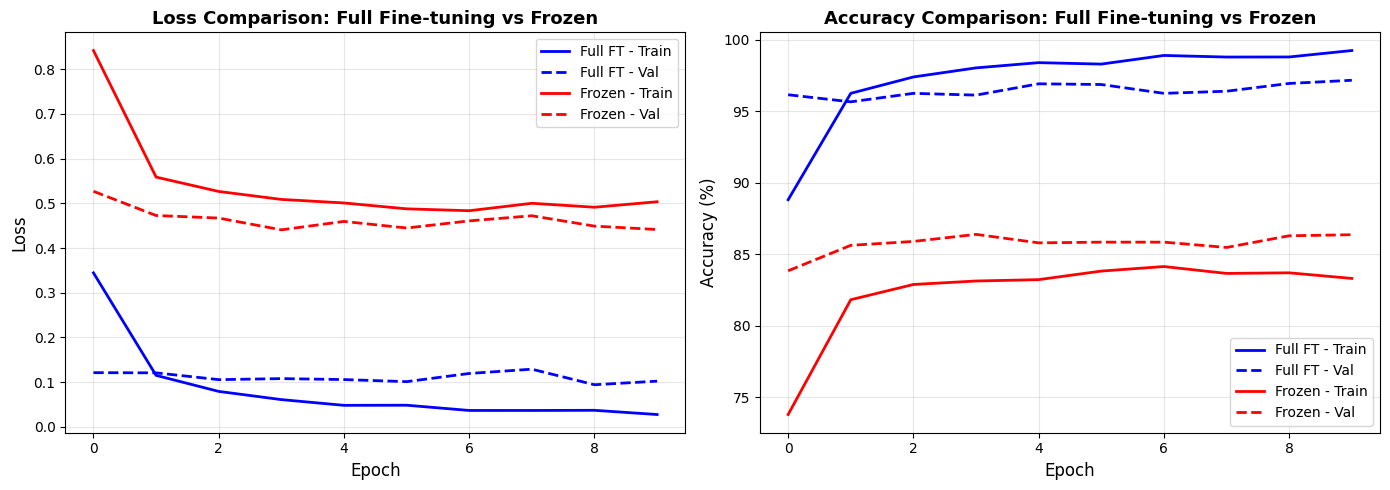


RESNET18 TRANSFER LEARNING - SUMMARY COMPARISON
Strategy             Val Acc      Test Acc     Params          Time (s)  
----------------------------------------------------------------------
Full Fine-tuning          97.16%       96.67%     11,181,642     142.2
Frozen Backbone           86.37%       85.58%          5,130      86.9


In [49]:
# Plot comparison of Full Fine-tuning vs Frozen Backbone
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Loss comparison
axes[0].plot(history_resnet_ff["train_loss"], 'b-', label="Full FT - Train", linewidth=2)
axes[0].plot(history_resnet_ff["val_loss"], 'b--', label="Full FT - Val", linewidth=2)
axes[0].plot(history_resnet_fb["train_loss"], 'r-', label="Frozen - Train", linewidth=2)
axes[0].plot(history_resnet_fb["val_loss"], 'r--', label="Frozen - Val", linewidth=2)
axes[0].set_xlabel("Epoch", fontsize=12)
axes[0].set_ylabel("Loss", fontsize=12)
axes[0].set_title("Loss Comparison: Full Fine-tuning vs Frozen", fontsize=13, fontweight='bold')
axes[0].legend()
axes[0].grid(alpha=0.3)

# Accuracy comparison
axes[1].plot([v*100 for v in history_resnet_ff["train_acc"]], 'b-', label="Full FT - Train", linewidth=2)
axes[1].plot([v*100 for v in history_resnet_ff["val_acc"]], 'b--', label="Full FT - Val", linewidth=2)
axes[1].plot([v*100 for v in history_resnet_fb["train_acc"]], 'r-', label="Frozen - Train", linewidth=2)
axes[1].plot([v*100 for v in history_resnet_fb["val_acc"]], 'r--', label="Frozen - Val", linewidth=2)
axes[1].set_xlabel("Epoch", fontsize=12)
axes[1].set_ylabel("Accuracy (%)", fontsize=12)
axes[1].set_title("Accuracy Comparison: Full Fine-tuning vs Frozen", fontsize=13, fontweight='bold')
axes[1].legend()
axes[1].grid(alpha=0.3)

plt.tight_layout()
plt.show()

# Print summary comparison
print("\n" + "="*70)
print("RESNET18 TRANSFER LEARNING - SUMMARY COMPARISON")
print("="*70)
print(f"{'Strategy':<20} {'Val Acc':<12} {'Test Acc':<12} {'Params':<15} {'Time (s)':<10}")
print("-"*70)
print(f"{'Full Fine-tuning':<20} {val_acc_resnet_ff*100:>10.2f}%  {test_acc_resnet_ff*100:>10.2f}%  {param_count_resnet_ff:>13,}  {train_time_resnet_ff:>8.1f}")
print(f"{'Frozen Backbone':<20} {val_acc_resnet_fb*100:>10.2f}%  {test_acc_resnet_fb*100:>10.2f}%  {param_count_resnet_fb:>13,}  {train_time_resnet_fb:>8.1f}")
print("="*70)

## Section 1.2b: Transfer Learning - EfficientNet-B0

In [21]:
# EfficientNet-B0 - Full Fine-tuning and Frozen Backbone
from torchvision.models import efficientnet_b0, EfficientNet_B0_Weights

class EfficientNetB0_FullFinetune(nn.Module):
    def __init__(self, num_classes=10):
        super().__init__()
        self.backbone = efficientnet_b0(weights=EfficientNet_B0_Weights.IMAGENET1K_V1)
        # Replace final layer
        in_features = self.backbone.classifier[1].in_features
        self.backbone.classifier[1] = nn.Linear(in_features, num_classes)
    
    def forward(self, x):
        return self.backbone(x)

class EfficientNetB0_FrozenBackbone(nn.Module):
    def __init__(self, num_classes=10):
        super().__init__()
        self.backbone = efficientnet_b0(weights=EfficientNet_B0_Weights.IMAGENET1K_V1)
        # Freeze all parameters
        for param in self.backbone.parameters():
            param.requires_grad = False
        # Replace final layer and make trainable
        in_features = self.backbone.classifier[1].in_features
        self.backbone.classifier[1] = nn.Linear(in_features, num_classes)
    
    def forward(self, x):
        return self.backbone(x)

print("EfficientNet-B0 models defined!")
model_eff_ff = EfficientNetB0_FullFinetune()
model_eff_fb = EfficientNetB0_FrozenBackbone()
print(f"EfficientNet-B0 Full Fine-tuning trainable params: {sum(p.numel() for p in model_eff_ff.parameters() if p.requires_grad):,}")
print(f"EfficientNet-B0 Frozen Backbone trainable params: {sum(p.numel() for p in model_eff_fb.parameters() if p.requires_grad):,}")


EfficientNet-B0 models defined!
Downloading: "https://download.pytorch.org/models/efficientnet_b0_rwightman-7f5810bc.pth" to /root/.cache/torch/hub/checkpoints/efficientnet_b0_rwightman-7f5810bc.pth


100%|██████████| 20.5M/20.5M [00:00<00:00, 153MB/s]


EfficientNet-B0 Full Fine-tuning trainable params: 4,020,358
EfficientNet-B0 Frozen Backbone trainable params: 12,810


In [22]:
# Train EfficientNet-B0 - Full Fine-tuning
print("\n" + "="*60)
print("TRAINING: EfficientNet-B0 - Full Fine-tuning")
print("="*60)

start_time = time.time()
model_eff_ff = EfficientNetB0_FullFinetune(num_classes=num_classes).to(device)
history_eff_ff = train_model(model_eff_ff, train_loader_resnet, val_loader_resnet, 
                             epochs=10, lr=1e-4, weight_decay=1e-4)
train_time_eff_ff = time.time() - start_time

val_acc_eff_ff = history_eff_ff["val_acc"][-1]
test_acc_eff_ff = accuracy(test_loader_resnet, model_eff_ff)
param_count_eff_ff = sum(p.numel() for p in model_eff_ff.parameters() if p.requires_grad)

print("\n" + "="*60)
print(f"EfficientNet-B0 Full Fine-tuning Results")
print("="*60)
print(f"Validation accuracy: {val_acc_eff_ff*100:.2f}%")
print(f"Test accuracy: {test_acc_eff_ff*100:.2f}%")
print(f"Trainable parameters: {param_count_eff_ff:,}")
print(f"Training time (s): {train_time_eff_ff:.1f}")



TRAINING: EfficientNet-B0 - Full Fine-tuning
Epoch 01: train_loss=0.6814 val_loss=0.1684 train_acc=80.02% val_acc=95.11%
Epoch 02: train_loss=0.2387 val_loss=0.1082 train_acc=92.52% val_acc=96.81%
Epoch 03: train_loss=0.1642 val_loss=0.0898 train_acc=94.73% val_acc=97.23%
Epoch 04: train_loss=0.1209 val_loss=0.0846 train_acc=96.03% val_acc=97.28%
Epoch 05: train_loss=0.1015 val_loss=0.0736 train_acc=96.95% val_acc=97.68%
Epoch 06: train_loss=0.0818 val_loss=0.0727 train_acc=97.28% val_acc=97.70%
Epoch 07: train_loss=0.0601 val_loss=0.0772 train_acc=98.13% val_acc=97.36%
Epoch 08: train_loss=0.0540 val_loss=0.0687 train_acc=98.33% val_acc=97.83%
Epoch 09: train_loss=0.0465 val_loss=0.0717 train_acc=98.52% val_acc=97.51%
Epoch 10: train_loss=0.0403 val_loss=0.0745 train_acc=98.67% val_acc=97.63%

EfficientNet-B0 Full Fine-tuning Results
Validation accuracy: 97.63%
Test accuracy: 97.33%
Trainable parameters: 4,020,358
Training time (s): 218.4


In [23]:
# Train EfficientNet-B0 - Frozen Backbone
print("\n" + "="*60)
print("TRAINING: EfficientNet-B0 - Frozen Backbone")
print("="*60)

start_time = time.time()
model_eff_fb = EfficientNetB0_FrozenBackbone(num_classes=num_classes).to(device)
history_eff_fb = train_model(model_eff_fb, train_loader_resnet, val_loader_resnet, 
                             epochs=10, lr=1e-3, weight_decay=1e-4)
train_time_eff_fb = time.time() - start_time

val_acc_eff_fb = history_eff_fb["val_acc"][-1]
test_acc_eff_fb = accuracy(test_loader_resnet, model_eff_fb)
param_count_eff_fb = sum(p.numel() for p in model_eff_fb.parameters() if p.requires_grad)

print("\n" + "="*60)
print(f"EfficientNet-B0 Frozen Backbone Results")
print("="*60)
print(f"Validation accuracy: {val_acc_eff_fb*100:.2f}%")
print(f"Test accuracy: {test_acc_eff_fb*100:.2f}%")
print(f"Trainable parameters: {param_count_eff_fb:,}")
print(f"Training time (s): {train_time_eff_fb:.1f}")



TRAINING: EfficientNet-B0 - Frozen Backbone
Epoch 01: train_loss=0.8691 val_loss=0.5837 train_acc=72.36% val_acc=81.09%
Epoch 02: train_loss=0.6829 val_loss=1.3830 train_acc=77.24% val_acc=81.36%
Epoch 03: train_loss=0.6801 val_loss=0.6578 train_acc=77.47% val_acc=82.17%
Epoch 04: train_loss=0.6703 val_loss=0.5903 train_acc=77.32% val_acc=81.58%
Epoch 05: train_loss=0.6725 val_loss=0.5454 train_acc=77.45% val_acc=81.88%
Epoch 06: train_loss=0.6540 val_loss=2.8168 train_acc=78.30% val_acc=81.48%
Epoch 07: train_loss=0.6597 val_loss=1.3202 train_acc=77.95% val_acc=81.60%
Epoch 08: train_loss=0.6611 val_loss=0.6205 train_acc=78.22% val_acc=82.15%
Epoch 09: train_loss=0.6643 val_loss=0.9995 train_acc=77.97% val_acc=81.04%
Epoch 10: train_loss=0.6602 val_loss=0.5566 train_acc=78.04% val_acc=81.28%

EfficientNet-B0 Frozen Backbone Results
Validation accuracy: 81.28%
Test accuracy: 80.54%
Trainable parameters: 12,810
Training time (s): 128.9


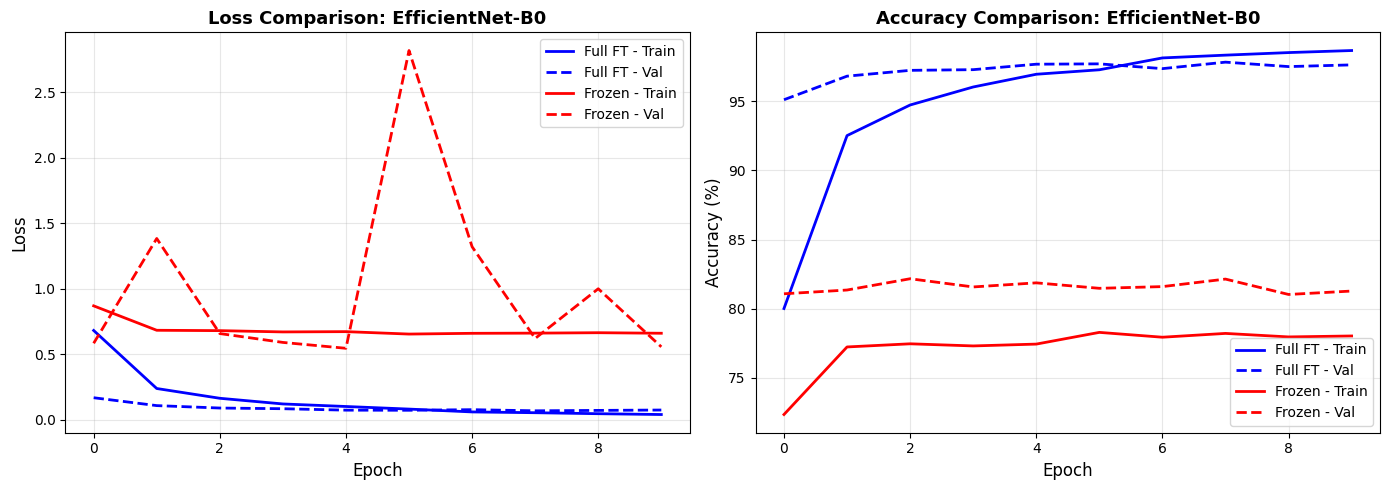


EFFICIENTNET-B0 TRANSFER LEARNING - SUMMARY COMPARISON
Strategy             Val Acc      Test Acc     Params          Time (s)  
----------------------------------------------------------------------
Full Fine-tuning          97.63%       97.33%      4,020,358     218.4
Frozen Backbone           81.28%       80.54%         12,810     128.9


In [24]:
# Plot EfficientNet-B0: Full Fine-tuning vs Frozen
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Loss comparison
axes[0].plot(history_eff_ff["train_loss"], 'b-', label="Full FT - Train", linewidth=2)
axes[0].plot(history_eff_ff["val_loss"], 'b--', label="Full FT - Val", linewidth=2)
axes[0].plot(history_eff_fb["train_loss"], 'r-', label="Frozen - Train", linewidth=2)
axes[0].plot(history_eff_fb["val_loss"], 'r--', label="Frozen - Val", linewidth=2)
axes[0].set_xlabel("Epoch", fontsize=12)
axes[0].set_ylabel("Loss", fontsize=12)
axes[0].set_title("Loss Comparison: EfficientNet-B0", fontsize=13, fontweight='bold')
axes[0].legend()
axes[0].grid(alpha=0.3)

# Accuracy comparison
axes[1].plot([v*100 for v in history_eff_ff["train_acc"]], 'b-', label="Full FT - Train", linewidth=2)
axes[1].plot([v*100 for v in history_eff_ff["val_acc"]], 'b--', label="Full FT - Val", linewidth=2)
axes[1].plot([v*100 for v in history_eff_fb["train_acc"]], 'r-', label="Frozen - Train", linewidth=2)
axes[1].plot([v*100 for v in history_eff_fb["val_acc"]], 'r--', label="Frozen - Val", linewidth=2)
axes[1].set_xlabel("Epoch", fontsize=12)
axes[1].set_ylabel("Accuracy (%)", fontsize=12)
axes[1].set_title("Accuracy Comparison: EfficientNet-B0", fontsize=13, fontweight='bold')
axes[1].legend()
axes[1].grid(alpha=0.3)

plt.tight_layout()
plt.show()

# Print summary comparison
print("\n" + "="*70)
print("EFFICIENTNET-B0 TRANSFER LEARNING - SUMMARY COMPARISON")
print("="*70)
print(f"{'Strategy':<20} {'Val Acc':<12} {'Test Acc':<12} {'Params':<15} {'Time (s)':<10}")
print("-"*70)
print(f"{'Full Fine-tuning':<20} {val_acc_eff_ff*100:>10.2f}%  {test_acc_eff_ff*100:>10.2f}%  {param_count_eff_ff:>13,}  {train_time_eff_ff:>8.1f}")
print(f"{'Frozen Backbone':<20} {val_acc_eff_fb*100:>10.2f}%  {test_acc_eff_fb*100:>10.2f}%  {param_count_eff_fb:>13,}  {train_time_eff_fb:>8.1f}")
print("="*70)


## Section 1.2c: Transfer Learning - Vision Transformer (ViT-B/16)

In [25]:
# Vision Transformer (ViT-B/16) - Full Fine-tuning and Frozen Backbone
from torchvision.models import vit_b_16, ViT_B_16_Weights

class ViT_FullFinetune(nn.Module):
    def __init__(self, num_classes=10):
        super().__init__()
        self.backbone = vit_b_16(weights=ViT_B_16_Weights.IMAGENET1K_V1)
        # Replace final layer (heads.head)
        in_features = self.backbone.heads.head.in_features
        self.backbone.heads.head = nn.Linear(in_features, num_classes)
    
    def forward(self, x):
        return self.backbone(x)

class ViT_FrozenBackbone(nn.Module):
    def __init__(self, num_classes=10):
        super().__init__()
        self.backbone = vit_b_16(weights=ViT_B_16_Weights.IMAGENET1K_V1)
        # Freeze all parameters
        for param in self.backbone.parameters():
            param.requires_grad = False
        # Replace final layer and make trainable
        in_features = self.backbone.heads.head.in_features
        self.backbone.heads.head = nn.Linear(in_features, num_classes)
    
    def forward(self, x):
        return self.backbone(x)

print("Vision Transformer (ViT-B/16) models defined!")
model_vit_ff = ViT_FullFinetune()
model_vit_fb = ViT_FrozenBackbone()
print(f"ViT Full Fine-tuning trainable params: {sum(p.numel() for p in model_vit_ff.parameters() if p.requires_grad):,}")
print(f"ViT Frozen Backbone trainable params: {sum(p.numel() for p in model_vit_fb.parameters() if p.requires_grad):,}")

Vision Transformer (ViT-B/16) models defined!
Downloading: "https://download.pytorch.org/models/vit_b_16-c867db91.pth" to /root/.cache/torch/hub/checkpoints/vit_b_16-c867db91.pth


100%|██████████| 330M/330M [00:01<00:00, 214MB/s] 


ViT Full Fine-tuning trainable params: 85,806,346
ViT Frozen Backbone trainable params: 7,690


In [26]:
# Create ViT-specific DataLoaders (224x224 required for ViT)
# ViT requires 224x224 input, unlike ResNet which we kept at 64x64

train_transform_vit = transforms.Compose([
    transforms.Resize(224),  # Resize to 224x224 for ViT
    transforms.ColorJitter(brightness=0.2, contrast=0.2, saturation=0.2),
    transforms.ToTensor(),
    transforms.Normalize(mean=[0.485, 0.456, 0.406],
                        std=[0.229, 0.224, 0.225])
])

val_test_transform_vit = transforms.Compose([
    transforms.Resize(224),  # Resize to 224x224 for ViT
    transforms.ToTensor(),
    transforms.Normalize(mean=[0.485, 0.456, 0.406],
                        std=[0.229, 0.224, 0.225])
])

# Create datasets with ViT transforms
train_dataset_vit = datasets.EuroSAT(root=data_dir, download=False, transform=train_transform_vit)
val_dataset_vit = datasets.EuroSAT(root=data_dir, download=False, transform=val_test_transform_vit)
test_dataset_vit = datasets.EuroSAT(root=data_dir, download=False, transform=val_test_transform_vit)

# Create subsets
train_set_vit = Subset(train_dataset_vit, train_full_indices)
val_set_vit = Subset(val_dataset_vit, val_indices)
test_set_vit = Subset(test_dataset_vit, test_indices)

# Create data loaders with batch_size=32 for ViT (memory efficient)
train_loader_vit = DataLoader(train_set_vit, batch_size=32, shuffle=True, 
                              num_workers=2, pin_memory=True)
val_loader_vit = DataLoader(val_set_vit, batch_size=32, shuffle=False,
                            num_workers=2, pin_memory=True)
test_loader_vit = DataLoader(test_set_vit, batch_size=32, shuffle=False,
                             num_workers=2, pin_memory=True)

print("ViT DataLoaders created.")
print(f"Train batches: {len(train_loader_vit)}, Val batches: {len(val_loader_vit)}, Test batches: {len(test_loader_vit)}")

ViT DataLoaders created (224x224 with batch_size=8)!
Train batches: 591, Val batches: 127, Test batches: 127


In [33]:
# Train Vision Transformer - Full Fine-tuning (with progress display)
print("\n" + "="*60)
print("TRAINING: Vision Transformer (ViT-B/16) - Full Fine-tuning")
print("="*60)

start_time = time.time()
model_vit_ff = ViT_FullFinetune(num_classes=num_classes).to(device)
history_vit_ff = train_model_verbose(model_vit_ff, train_loader_vit, val_loader_vit, 
                                      epochs=10, lr=1e-4, weight_decay=1e-4)
train_time_vit_ff = time.time() - start_time

val_acc_vit_ff = history_vit_ff["val_acc"][-1]
test_acc_vit_ff = accuracy(test_loader_vit, model_vit_ff)
param_count_vit_ff = sum(p.numel() for p in model_vit_ff.parameters() if p.requires_grad)

print("\n" + "="*60)
print(f"ViT Full Fine-tuning Results")
print("="*60)
print(f"Validation accuracy: {val_acc_vit_ff*100:.2f}%")
print(f"Test accuracy: {test_acc_vit_ff*100:.2f}%")
print(f"Trainable parameters: {param_count_vit_ff:,}")
print(f"Training time (s): {train_time_vit_ff:.1f}")


TRAINING: Vision Transformer (ViT-B/16) - Full Fine-tuning

Epoch 1/10
  Batch 59/591 (10%) - loss: 0.6103
  Batch 118/591 (20%) - loss: 0.2181
  Batch 177/591 (30%) - loss: 0.0577
  Batch 236/591 (40%) - loss: 0.2513
  Batch 295/591 (50%) - loss: 0.0265
  Batch 354/591 (60%) - loss: 0.0868
  Batch 413/591 (70%) - loss: 0.0858
  Batch 472/591 (80%) - loss: 0.3072
  Batch 531/591 (90%) - loss: 0.0398
  Batch 590/591 (100%) - loss: 0.3391
  Batch 591/591 (100%) - loss: 0.0501
  Validating...

  Summary: train_loss=0.2139 val_loss=0.1603 train_acc=93.13% val_acc=94.57%

Epoch 2/10
  Batch 59/591 (10%) - loss: 0.0667
  Batch 118/591 (20%) - loss: 0.0379
  Batch 177/591 (30%) - loss: 0.3114
  Batch 236/591 (40%) - loss: 0.0146
  Batch 295/591 (50%) - loss: 0.0171
  Batch 354/591 (60%) - loss: 0.0265
  Batch 413/591 (70%) - loss: 0.0138
  Batch 472/591 (80%) - loss: 0.0272
  Batch 531/591 (90%) - loss: 0.0058
  Batch 590/591 (100%) - loss: 0.0496
  Batch 591/591 (100%) - loss: 0.0032
  Vali

In [34]:
# Train Vision Transformer - Frozen Backbone (with progress display)
print("\n" + "="*60)
print("TRAINING: Vision Transformer (ViT-B/16) - Frozen Backbone")
print("="*60)

start_time = time.time()
model_vit_fb = ViT_FrozenBackbone(num_classes=num_classes).to(device)
history_vit_fb = train_model_verbose(model_vit_fb, train_loader_vit, val_loader_vit, 
                                      epochs=10, lr=1e-3, weight_decay=1e-4)
train_time_vit_fb = time.time() - start_time

val_acc_vit_fb = history_vit_fb["val_acc"][-1]
test_acc_vit_fb = accuracy(test_loader_vit, model_vit_fb)
param_count_vit_fb = sum(p.numel() for p in model_vit_fb.parameters() if p.requires_grad)

print("\n" + "="*60)
print(f"ViT Frozen Backbone Results")
print("="*60)
print(f"Validation accuracy: {val_acc_vit_fb*100:.2f}%")
print(f"Test accuracy: {test_acc_vit_fb*100:.2f}%")
print(f"Trainable parameters: {param_count_vit_fb:,}")
print(f"Training time (s): {train_time_vit_fb:.1f}")


TRAINING: Vision Transformer (ViT-B/16) - Frozen Backbone

Epoch 1/10
  Batch 59/591 (10%) - loss: 0.5107
  Batch 118/591 (20%) - loss: 0.3120
  Batch 177/591 (30%) - loss: 0.4063
  Batch 236/591 (40%) - loss: 0.1350
  Batch 295/591 (50%) - loss: 0.1761
  Batch 354/591 (60%) - loss: 0.2405
  Batch 413/591 (70%) - loss: 0.1506
  Batch 472/591 (80%) - loss: 0.1206
  Batch 531/591 (90%) - loss: 0.1652
  Batch 590/591 (100%) - loss: 0.1259
  Batch 591/591 (100%) - loss: 0.0962
  Validating...

  Summary: train_loss=0.3240 val_loss=0.1519 train_acc=91.05% val_acc=95.53%

Epoch 2/10
  Batch 59/591 (10%) - loss: 0.0954
  Batch 118/591 (20%) - loss: 0.1898
  Batch 177/591 (30%) - loss: 0.1815
  Batch 236/591 (40%) - loss: 0.0911
  Batch 295/591 (50%) - loss: 0.1032
  Batch 354/591 (60%) - loss: 0.0414
  Batch 413/591 (70%) - loss: 0.1225
  Batch 472/591 (80%) - loss: 0.1219
  Batch 531/591 (90%) - loss: 0.1834
  Batch 590/591 (100%) - loss: 0.1156
  Batch 591/591 (100%) - loss: 0.1572
  Valid

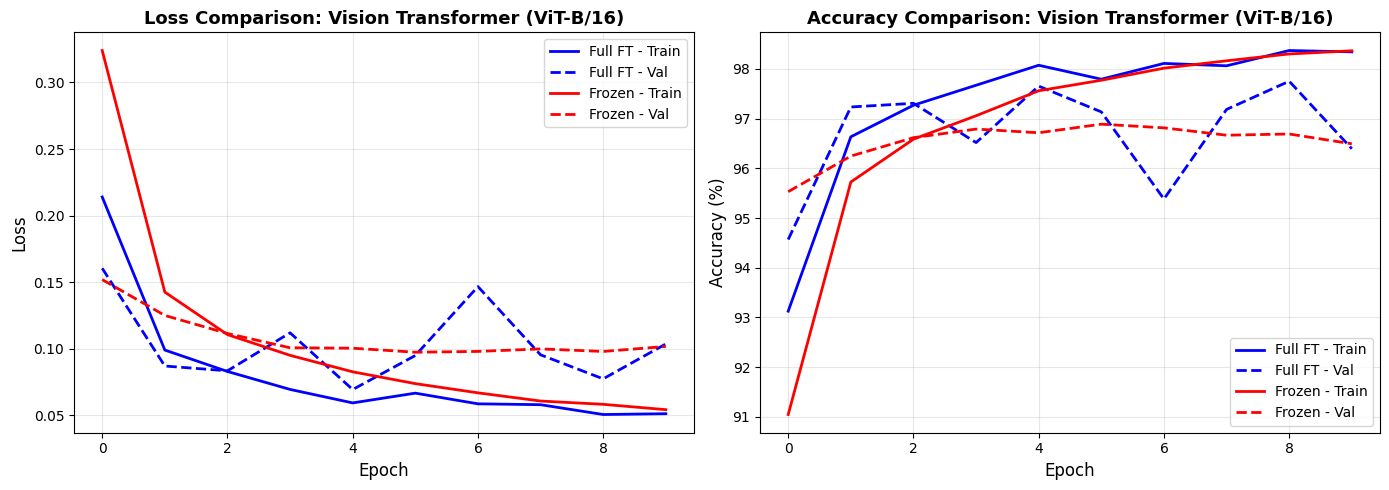


VISION TRANSFORMER (ViT-B/16) TRANSFER LEARNING - SUMMARY COMPARISON
Strategy             Val Acc      Test Acc     Params          Time (s)  
----------------------------------------------------------------------
Full Fine-tuning          96.40%       96.40%     85,806,346    8092.3
Frozen Backbone           96.49%       96.52%          7,690    3850.7


In [35]:
# Plot Vision Transformer: Full Fine-tuning vs Frozen
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Loss comparison
axes[0].plot(history_vit_ff["train_loss"], 'b-', label="Full FT - Train", linewidth=2)
axes[0].plot(history_vit_ff["val_loss"], 'b--', label="Full FT - Val", linewidth=2)
axes[0].plot(history_vit_fb["train_loss"], 'r-', label="Frozen - Train", linewidth=2)
axes[0].plot(history_vit_fb["val_loss"], 'r--', label="Frozen - Val", linewidth=2)
axes[0].set_xlabel("Epoch", fontsize=12)
axes[0].set_ylabel("Loss", fontsize=12)
axes[0].set_title("Loss Comparison: Vision Transformer (ViT-B/16)", fontsize=13, fontweight='bold')
axes[0].legend()
axes[0].grid(alpha=0.3)

# Accuracy comparison
axes[1].plot([v*100 for v in history_vit_ff["train_acc"]], 'b-', label="Full FT - Train", linewidth=2)
axes[1].plot([v*100 for v in history_vit_ff["val_acc"]], 'b--', label="Full FT - Val", linewidth=2)
axes[1].plot([v*100 for v in history_vit_fb["train_acc"]], 'r-', label="Frozen - Train", linewidth=2)
axes[1].plot([v*100 for v in history_vit_fb["val_acc"]], 'r--', label="Frozen - Val", linewidth=2)
axes[1].set_xlabel("Epoch", fontsize=12)
axes[1].set_ylabel("Accuracy (%)", fontsize=12)
axes[1].set_title("Accuracy Comparison: Vision Transformer (ViT-B/16)", fontsize=13, fontweight='bold')
axes[1].legend()
axes[1].grid(alpha=0.3)

plt.tight_layout()
plt.show()

# Print summary comparison
print("\n" + "="*70)
print("VISION TRANSFORMER (ViT-B/16) TRANSFER LEARNING - SUMMARY COMPARISON")
print("="*70)
print(f"{'Strategy':<20} {'Val Acc':<12} {'Test Acc':<12} {'Params':<15} {'Time (s)':<10}")
print("-"*70)
print(f"{'Full Fine-tuning':<20} {val_acc_vit_ff*100:>10.2f}%  {test_acc_vit_ff*100:>10.2f}%  {param_count_vit_ff:>13,}  {train_time_vit_ff:>8.1f}")
print(f"{'Frozen Backbone':<20} {val_acc_vit_fb*100:>10.2f}%  {test_acc_vit_fb*100:>10.2f}%  {param_count_vit_fb:>13,}  {train_time_vit_fb:>8.1f}")
print("="*70)

# Q1.4 - Πινακας συγκρισης μοντελων

In [47]:
# Comprehensive comparison table for all models
import pandas as pd

# Data from all training runs
data = {
    'Μοντέλο': ['ResNet18', 'ResNet18', 'EfficientNet-B0', 'EfficientNet-B0', 'ViT-B/16', 'ViT-B/16'],
    'Στρατηγική': ['Full FT', 'Frozen', 'Full FT', 'Frozen', 'Full FT', 'Frozen'],
    'Test Accuracy (%)': [96.67, 85.48, 97.3, 81.31, 96.4, 96.52],
    'Training Time (s)': [140, 86, 218, 128, 8092, 3850],
    'Trainable Parameters': ['11,181,642', '5,130', '4,020,358', '12,810', '85,806,346', '7,690']
}

df_results = pd.DataFrame(data)

print("\n" + "="*110)
print("TASK 1.2: TRANSFER LEARNING COMPARISON - ALL MODELS")
print("="*110)
print(df_results.to_string(index=False))
print("="*110)



TASK 1.2: TRANSFER LEARNING COMPARISON - ALL MODELS
        Μοντέλο Στρατηγική  Test Accuracy (%)  Training Time (s) Trainable Parameters
       ResNet18    Full FT              96.70                140           11,181,642
       ResNet18     Frozen              85.48                 86                5,130
EfficientNet-B0    Full FT              97.30                218            4,020,358
EfficientNet-B0     Frozen              81.31                128               12,810
       ViT-B/16    Full FT              96.40               8092           85,806,346
       ViT-B/16     Frozen              96.52               3850                7,690


# Q1.5 Ποιο μοντέλο και ποια στρατηγική (full fine-tuning ή frozen) απέδωσαν καλύτερα και γιατί πιστεύετε ότι συνέβη αυτό;

Το EfficientNet-B0 με full fine-tuning παρουσίασε την καλύτερη συνολική απόδοση αμεσως πριν το RestNet18 και χαμηλοτερο το vit-b/16
Το full fine-tuning επέτρεψε στα CNN-based μοντέλα να προσαρμόσουν ολόκληρο το backbone στο συγκεκριμένο dataset, γεγονός που οδήγησε σε καλύτερη τελική απόδοση.

# Q1.6 Πώς επηρέασε το freezing του backbone τον χρόνο εκπαίδευσης και την τελική απόδοση;

Το freezing του backbone μείωσε σημαντικά τον χρόνο εκπαίδευσης σε όλα τα μοντέλα, καθώς περιορίστηκε ο αριθμός των παραμέτρων που εκπαιδεύονται. Ωστόσο, στα CNN-based μοντέλα (ResNet18 και EfficientNet-B0) το freezing οδήγησε σε μεγάλη πτώση της τελικής ακρίβειας, καθώς το μοντέλο μπορούσε να προσαρμόσει μόνο το classification head.
Στην περίπτωση του Vision Transformer, το freezing μείωσε δραστικά τον χρόνο εκπαίδευσης χωρίς να επηρεάσει ουσιαστικά την απόδοση.

# Q1.7 Συγκρίνετε ποιοτικά τη συμπεριφορά του Vision Transformer με τα CNN-based μοντέλα στο EuroSAT. Υπάρχουν διαφορές στην απόδοση, το training time, ή τη data efficiency;

Τα CNN-based μοντέλα παρουσίασαν υψηλότερη ή συγκρίσιμη ακρίβεια με πολύ μικρότερο χρόνο εκπαίδευσης σε σχέση με το Vision Transformer. Το ViT ήταν σημαντικά πιο αργό στην εκπαίδευση και απαιτούσε πολύ χωρίς να προσφέρει ιδιαίτερο πλεονέκτημα στην τελική απόδοση στο συγκεκριμένο dataset.
Συνολικά, στο EuroSAT τα CNN-based μοντέλα αποδείχθηκαν πιο αποδοτικά ως προς τον χρόνο εκπαίδευσης και την πρακτική αξιοποίηση των δεδομένων, ενώ το ViT εμφάνισε μεγαλύτερο υπολογιστικό κόστος.


# Task 1.3 – Transfer Learning σε Few-Shot Σενάρια

**Στόχος**: Εκπαίδευση των 2 καλύτερων configurations (EfficientNet-B0 Full FT και ResNet18 Full FT) σε 10-shot και 5-shot splits και σύγκριση απόδοσης με τα full training results.

In [37]:
# Create DataLoaders for few-shot splits
print("Creating few-shot DataLoaders...")

# For 10-shot training
train_set_10shot = Subset(train_dataset_resnet, train_10shot_indices)
train_loader_10shot = DataLoader(train_set_10shot, batch_size=8, shuffle=True, 
                                 num_workers=2, pin_memory=True)

# For 5-shot training
train_set_5shot = Subset(train_dataset_resnet, train_5shot_indices)
train_loader_5shot = DataLoader(train_set_5shot, batch_size=4, shuffle=True, 
                                num_workers=2, pin_memory=True)

print(f"10-shot train batches: {len(train_loader_10shot)}")
print(f"5-shot train batches: {len(train_loader_5shot)}")
print(f"Val batches (same for all): {len(val_loader_resnet)}")
print(f"Test batches (same for all): {len(test_loader_resnet)}")

Creating few-shot DataLoaders...
10-shot train batches: 13
5-shot train batches: 13
Val batches (same for all): 127
Test batches (same for all): 127


In [38]:
# Train EfficientNet-B0 on 10-shot
print("\n" + "="*60)
print("TRAINING: EfficientNet-B0 Full FT - 10-SHOT")
print("="*60)

start_time = time.time()
model_eff_10shot = EfficientNetB0_FullFinetune(num_classes=num_classes).to(device)
history_eff_10shot = train_model(model_eff_10shot, train_loader_10shot, val_loader_resnet, 
                                 epochs=30, lr=1e-4, weight_decay=0)
train_time_eff_10shot = time.time() - start_time

val_acc_eff_10shot = history_eff_10shot["val_acc"][-1]
test_acc_eff_10shot = accuracy(test_loader_resnet, model_eff_10shot)
param_count_eff_10shot = sum(p.numel() for p in model_eff_10shot.parameters() if p.requires_grad)

print("\n" + "="*60)
print(f"EfficientNet-B0 Full FT - 10-SHOT Results")
print("="*60)
print(f"Validation accuracy: {val_acc_eff_10shot*100:.2f}%")
print(f"Test accuracy: {test_acc_eff_10shot*100:.2f}%")
print(f"Trainable parameters: {param_count_eff_10shot:,}")
print(f"Training time (s): {train_time_eff_10shot:.1f}")


TRAINING: EfficientNet-B0 Full FT - 10-SHOT
Epoch 01: train_loss=2.3167 val_loss=2.2674 train_acc=14.00% val_acc=16.25%
Epoch 02: train_loss=2.0862 val_loss=2.3062 train_acc=28.00% val_acc=23.78%
Epoch 03: train_loss=2.0054 val_loss=2.3868 train_acc=39.00% val_acc=30.44%
Epoch 04: train_loss=1.8303 val_loss=2.4347 train_acc=56.00% val_acc=33.90%
Epoch 05: train_loss=1.8030 val_loss=2.7493 train_acc=50.00% val_acc=35.19%
Epoch 06: train_loss=1.6208 val_loss=2.5644 train_acc=65.00% val_acc=40.12%
Epoch 07: train_loss=1.5384 val_loss=2.6452 train_acc=65.00% val_acc=43.33%
Epoch 08: train_loss=1.4496 val_loss=2.1367 train_acc=77.00% val_acc=49.46%
Epoch 09: train_loss=1.3937 val_loss=2.1455 train_acc=67.00% val_acc=54.59%
Epoch 10: train_loss=1.1996 val_loss=1.7678 train_acc=81.00% val_acc=57.63%
Epoch 11: train_loss=1.2080 val_loss=2.1063 train_acc=75.00% val_acc=59.51%
Epoch 12: train_loss=1.0986 val_loss=1.8639 train_acc=80.00% val_acc=58.22%
Epoch 13: train_loss=1.0551 val_loss=2.0300

In [40]:
# Train EfficientNet-B0 on 5-shot
print("\n" + "="*60)
print("TRAINING: EfficientNet-B0 Full FT - 5-SHOT")
print("="*60)

start_time = time.time()
model_eff_5shot = EfficientNetB0_FullFinetune(num_classes=num_classes).to(device)
history_eff_5shot = train_model(model_eff_5shot, train_loader_5shot, val_loader_resnet, 
                                epochs=30, lr=1e-4, weight_decay=0)
train_time_eff_5shot = time.time() - start_time

val_acc_eff_5shot = history_eff_5shot["val_acc"][-1]
test_acc_eff_5shot = accuracy(test_loader_resnet, model_eff_5shot)
param_count_eff_5shot = sum(p.numel() for p in model_eff_5shot.parameters() if p.requires_grad)

print("\n" + "="*60)
print(f"EfficientNet-B0 Full FT - 5-SHOT Results")
print("="*60)
print(f"Validation accuracy: {val_acc_eff_5shot*100:.2f}%")
print(f"Test accuracy: {test_acc_eff_5shot*100:.2f}%")
print(f"Trainable parameters: {param_count_eff_5shot:,}")
print(f"Training time (s): {train_time_eff_5shot:.1f}")


TRAINING: EfficientNet-B0 Full FT - 5-SHOT
Epoch 01: train_loss=2.3507 val_loss=2.3094 train_acc=10.00% val_acc=14.72%
Epoch 02: train_loss=2.1867 val_loss=3.1147 train_acc=24.00% val_acc=10.67%
Epoch 03: train_loss=2.2535 val_loss=4.1457 train_acc=18.00% val_acc=12.67%
Epoch 04: train_loss=2.1319 val_loss=17.2616 train_acc=26.00% val_acc=13.53%
Epoch 05: train_loss=2.1326 val_loss=17.2267 train_acc=32.00% val_acc=14.12%
Epoch 06: train_loss=1.9807 val_loss=7.5693 train_acc=46.00% val_acc=16.20%
Epoch 07: train_loss=1.9819 val_loss=29.6101 train_acc=38.00% val_acc=16.69%
Epoch 08: train_loss=1.8800 val_loss=21.1849 train_acc=52.00% val_acc=19.01%
Epoch 09: train_loss=1.8057 val_loss=14.0314 train_acc=50.00% val_acc=22.54%
Epoch 10: train_loss=1.7480 val_loss=21.7030 train_acc=50.00% val_acc=25.21%
Epoch 11: train_loss=1.7242 val_loss=14.6043 train_acc=54.00% val_acc=24.72%
Epoch 12: train_loss=1.5987 val_loss=3.6715 train_acc=66.00% val_acc=27.51%
Epoch 13: train_loss=1.6022 val_loss=

In [42]:
# Train ResNet18 on 10-shot
print("\n" + "="*60)
print("TRAINING: ResNet18 Full FT - 10-SHOT")
print("="*60)

start_time = time.time()
model_resnet_10shot = ResNet18_FullFinetune(num_classes=num_classes).to(device)
history_resnet_10shot = train_model(model_resnet_10shot, train_loader_10shot, val_loader_resnet, 
                                    epochs=30, lr=1e-4, weight_decay=1e-4)
train_time_resnet_10shot = time.time() - start_time

val_acc_resnet_10shot = history_resnet_10shot["val_acc"][-1]
test_acc_resnet_10shot = accuracy(test_loader_resnet, model_resnet_10shot)
param_count_resnet_10shot = sum(p.numel() for p in model_resnet_10shot.parameters() if p.requires_grad)

print("\n" + "="*60)
print(f"ResNet18 Full FT - 10-SHOT Results")
print("="*60)
print(f"Validation accuracy: {val_acc_resnet_10shot*100:.2f}%")
print(f"Test accuracy: {test_acc_resnet_10shot*100:.2f}%")
print(f"Trainable parameters: {param_count_resnet_10shot:,}")
print(f"Training time (s): {train_time_resnet_10shot:.1f}")


TRAINING: ResNet18 Full FT - 10-SHOT
Epoch 01: train_loss=2.3469 val_loss=1.9069 train_acc=13.00% val_acc=29.98%
Epoch 02: train_loss=1.1763 val_loss=1.4265 train_acc=67.00% val_acc=54.07%
Epoch 03: train_loss=0.7719 val_loss=1.2298 train_acc=82.00% val_acc=59.56%
Epoch 04: train_loss=0.4458 val_loss=1.0855 train_acc=93.00% val_acc=65.98%
Epoch 05: train_loss=0.3793 val_loss=1.0233 train_acc=94.00% val_acc=67.38%
Epoch 06: train_loss=0.3200 val_loss=0.9734 train_acc=94.00% val_acc=69.33%
Epoch 07: train_loss=0.1865 val_loss=0.9202 train_acc=98.00% val_acc=71.23%
Epoch 08: train_loss=0.2635 val_loss=0.8887 train_acc=94.00% val_acc=70.99%
Epoch 09: train_loss=0.1613 val_loss=0.9578 train_acc=99.00% val_acc=68.15%
Epoch 10: train_loss=0.1079 val_loss=0.9346 train_acc=100.00% val_acc=68.96%
Epoch 11: train_loss=0.1071 val_loss=0.8703 train_acc=97.00% val_acc=71.43%
Epoch 12: train_loss=0.0800 val_loss=0.8415 train_acc=100.00% val_acc=72.74%
Epoch 13: train_loss=0.0828 val_loss=0.8122 trai

In [43]:
# Train ResNet18 on 5-shot
print("\n" + "="*60)
print("TRAINING: ResNet18 Full FT - 5-SHOT")
print("="*60)

start_time = time.time()
model_resnet_5shot = ResNet18_FullFinetune(num_classes=num_classes).to(device)
history_resnet_5shot = train_model(model_resnet_5shot, train_loader_5shot, val_loader_resnet, 
                                   epochs=30, lr=1e-4, weight_decay=1e-4)
train_time_resnet_5shot = time.time() - start_time

val_acc_resnet_5shot = history_resnet_5shot["val_acc"][-1]
test_acc_resnet_5shot = accuracy(test_loader_resnet, model_resnet_5shot)
param_count_resnet_5shot = sum(p.numel() for p in model_resnet_5shot.parameters() if p.requires_grad)

print("\n" + "="*60)
print(f"ResNet18 Full FT - 5-SHOT Results")
print("="*60)
print(f"Validation accuracy: {val_acc_resnet_5shot*100:.2f}%")
print(f"Test accuracy: {test_acc_resnet_5shot*100:.2f}%")
print(f"Trainable parameters: {param_count_resnet_5shot:,}")
print(f"Training time (s): {train_time_resnet_5shot:.1f}")


TRAINING: ResNet18 Full FT - 5-SHOT
Epoch 01: train_loss=2.3468 val_loss=2.2165 train_acc=16.00% val_acc=18.81%
Epoch 02: train_loss=1.4986 val_loss=1.9378 train_acc=60.00% val_acc=36.10%
Epoch 03: train_loss=1.2337 val_loss=1.8872 train_acc=68.00% val_acc=40.17%
Epoch 04: train_loss=0.7809 val_loss=1.7133 train_acc=82.00% val_acc=46.54%
Epoch 05: train_loss=0.6197 val_loss=1.5463 train_acc=92.00% val_acc=51.19%
Epoch 06: train_loss=0.6409 val_loss=1.6353 train_acc=86.00% val_acc=49.16%
Epoch 07: train_loss=0.3269 val_loss=1.5711 train_acc=96.00% val_acc=50.15%
Epoch 08: train_loss=0.3955 val_loss=1.3909 train_acc=90.00% val_acc=54.86%
Epoch 09: train_loss=0.3983 val_loss=1.4892 train_acc=92.00% val_acc=52.15%
Epoch 10: train_loss=0.3000 val_loss=1.5963 train_acc=94.00% val_acc=48.77%
Epoch 11: train_loss=0.3167 val_loss=1.4792 train_acc=92.00% val_acc=53.38%
Epoch 12: train_loss=0.2335 val_loss=1.4243 train_acc=98.00% val_acc=55.56%
Epoch 13: train_loss=0.3212 val_loss=1.4184 train_a

In [44]:
# Few-shot comparison table
print("\n" + "="*100)
print("TASK 1.3: TRANSFER LEARNING - FEW-SHOT COMPARISON")
print("="*100)

comparison_data = {
    'Model': [
        'EfficientNet-B0 FF (Full)',
        'EfficientNet-B0 FF (10-shot)',
        'EfficientNet-B0 FF (5-shot)',
        'ResNet18 FF (Full)',
        'ResNet18 FF (10-shot)',
        'ResNet18 FF (5-shot)'
    ],
    'Train Samples': [
        len(train_full_indices),
        len(train_10shot_indices),
        len(train_5shot_indices),
        len(train_full_indices),
        len(train_10shot_indices),
        len(train_5shot_indices)
    ],
    'Test Accuracy (%)': [
        test_acc_eff_ff * 100,
        test_acc_eff_10shot * 100,
        test_acc_eff_5shot * 100,
        test_acc_resnet_ff * 100,
        test_acc_resnet_10shot * 100,
        test_acc_resnet_5shot * 100
    ],
    'Training Time (s)': [
        train_time_eff_ff,
        train_time_eff_10shot,
        train_time_eff_5shot,
        train_time_resnet_ff,
        train_time_resnet_10shot,
        train_time_resnet_5shot
    ]
}

df_fewshot = pd.DataFrame(comparison_data)

print(df_fewshot.to_string(index=False))
print("="*100)

# Calculate accuracy drop
print("\nAccuracy Drop Analysis:")
print("-" * 100)
acc_drop_eff_10 = test_acc_eff_ff * 100 - test_acc_eff_10shot * 100
acc_drop_eff_5 = test_acc_eff_ff * 100 - test_acc_eff_5shot * 100
acc_drop_resnet_10 = test_acc_resnet_ff * 100 - test_acc_resnet_10shot * 100
acc_drop_resnet_5 = test_acc_resnet_ff * 100 - test_acc_resnet_5shot * 100

print(f"EfficientNet-B0 Full -> 10-shot: {acc_drop_eff_10:.2f}% drop ({test_acc_eff_ff*100:.2f}% -> {test_acc_eff_10shot*100:.2f}%)")
print(f"EfficientNet-B0 Full -> 5-shot:  {acc_drop_eff_5:.2f}% drop ({test_acc_eff_ff*100:.2f}% -> {test_acc_eff_5shot*100:.2f}%)")
print(f"ResNet18 Full -> 10-shot:        {acc_drop_resnet_10:.2f}% drop ({test_acc_resnet_ff*100:.2f}% -> {test_acc_resnet_10shot*100:.2f}%)")
print(f"ResNet18 Full -> 5-shot:         {acc_drop_resnet_5:.2f}% drop ({test_acc_resnet_ff*100:.2f}% -> {test_acc_resnet_5shot*100:.2f}%)")
print("="*100)


TASK 1.3: TRANSFER LEARNING - FEW-SHOT COMPARISON
                       Model  Train Samples  Test Accuracy (%)  Training Time (s)
   EfficientNet-B0 FF (Full)          18900          97.333333         218.391939
EfficientNet-B0 FF (10-shot)            100          75.012346          73.391248
 EfficientNet-B0 FF (5-shot)             50          37.728395          74.489760
          ResNet18 FF (Full)          18900          96.222222         140.384815
       ResNet18 FF (10-shot)            100          74.271605          59.323480
        ResNet18 FF (5-shot)             50          62.691358          58.206996

Accuracy Drop Analysis:
----------------------------------------------------------------------------------------------------
EfficientNet-B0 Full -> 10-shot: 22.32% drop (97.33% -> 75.01%)
EfficientNet-B0 Full -> 5-shot:  59.60% drop (97.33% -> 37.73%)
ResNet18 Full -> 10-shot:        21.95% drop (96.22% -> 74.27%)
ResNet18 Full -> 5-shot:         33.53% drop (96.22% -> 6

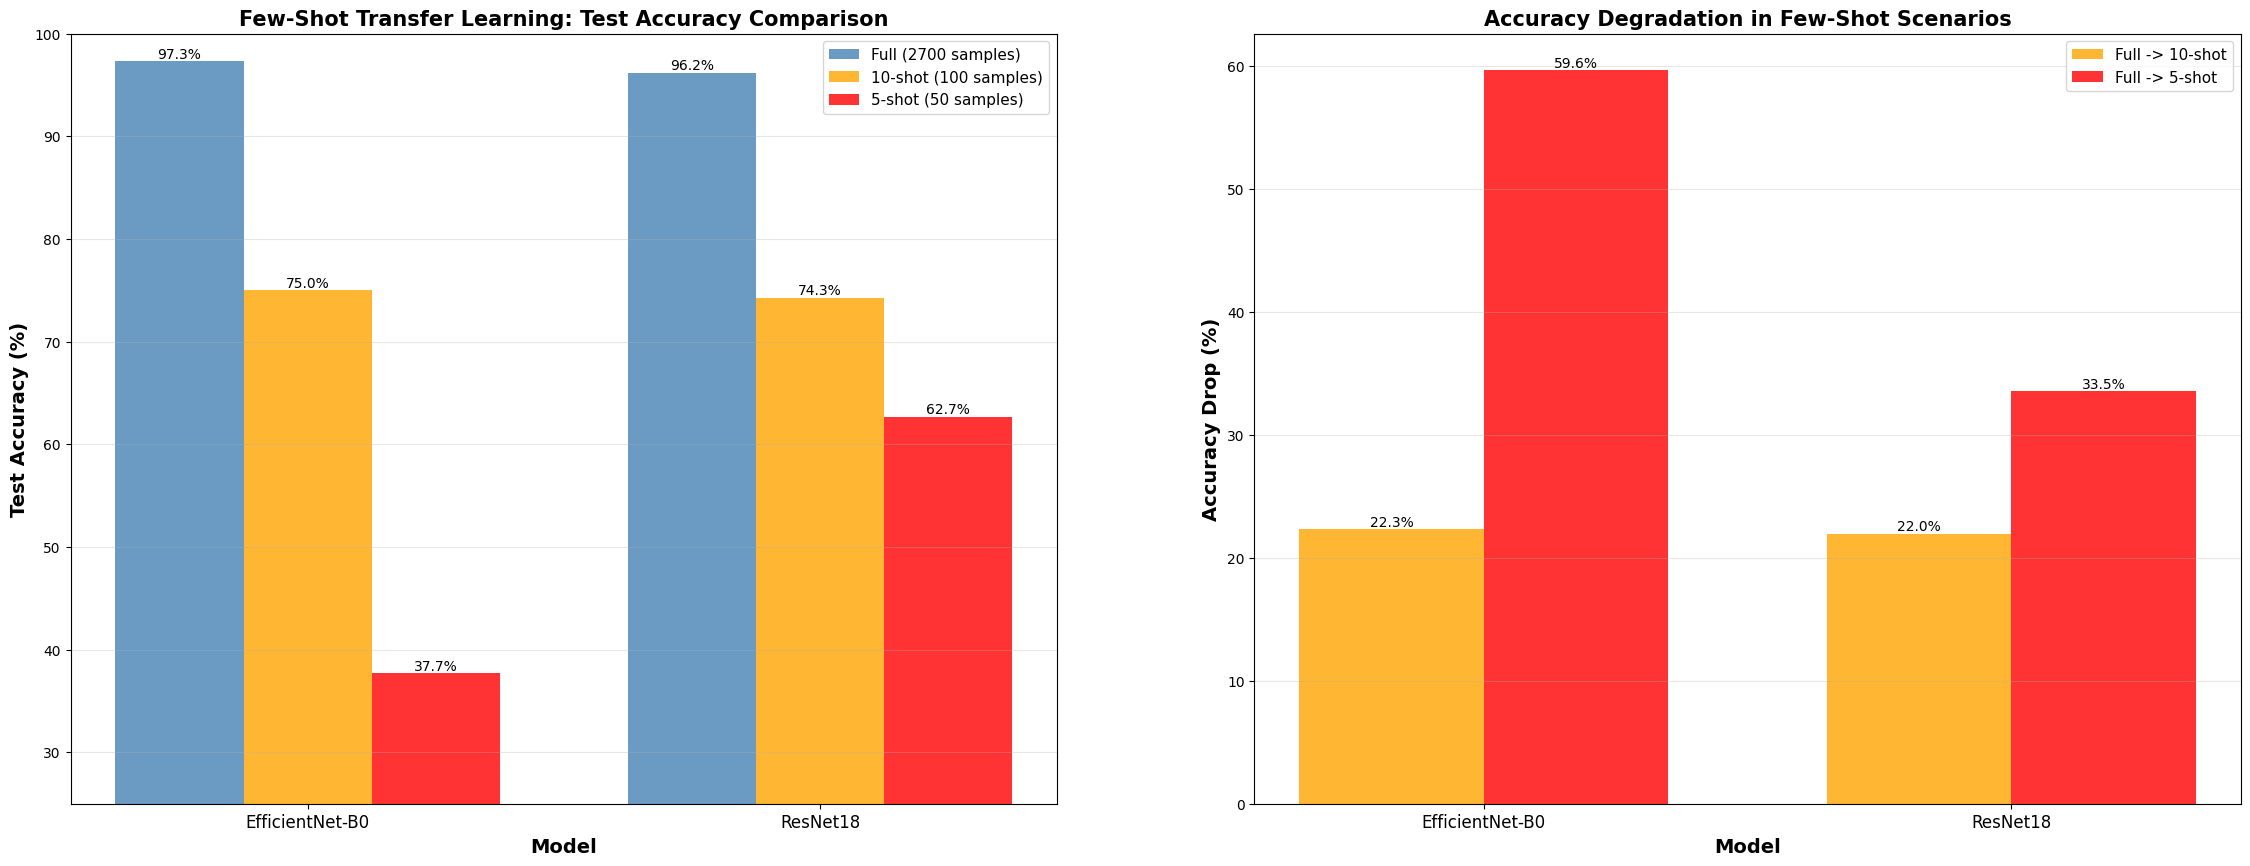

Few-shot visualization complete!


In [46]:
# Visualization: Few-shot accuracy comparison
fig, axes = plt.subplots(1, 2, figsize=(28, 10), dpi=100)

# Plot 1: Test Accuracy across different data regimes
models_fs = ['EfficientNet-B0', 'ResNet18']
full_accs = [test_acc_eff_ff * 100, test_acc_resnet_ff * 100]
shot_10_accs = [test_acc_eff_10shot * 100, test_acc_resnet_10shot * 100]
shot_5_accs = [test_acc_eff_5shot * 100, test_acc_resnet_5shot * 100]

x = np.arange(len(models_fs))
width = 0.25

bars1 = axes[0].bar(x - width, full_accs, width, label='Full (2700 samples)', color='steelblue', alpha=0.8)
bars2 = axes[0].bar(x, shot_10_accs, width, label='10-shot (100 samples)', color='orange', alpha=0.8)
bars3 = axes[0].bar(x + width, shot_5_accs, width, label='5-shot (50 samples)', color='red', alpha=0.8)

axes[0].set_xlabel('Model', fontsize=14, fontweight='bold')
axes[0].set_ylabel('Test Accuracy (%)', fontsize=14, fontweight='bold')
axes[0].set_title('Few-Shot Transfer Learning: Test Accuracy Comparison', fontsize=15, fontweight='bold')
axes[0].set_xticks(x)
axes[0].set_xticklabels(models_fs, fontsize=12)
axes[0].legend(fontsize=11)
axes[0].grid(axis='y', alpha=0.3)
axes[0].set_ylim([25, 100])

# Add value labels on bars
for bars in [bars1, bars2, bars3]:
    for bar in bars:
        height = bar.get_height()
        axes[0].text(bar.get_x() + bar.get_width()/2., height,
                    f'{height:.1f}%', ha='center', va='bottom', fontsize=10)

# Plot 2: Accuracy drop from full to few-shot
drop_10 = [acc_drop_eff_10, acc_drop_resnet_10]
drop_5 = [acc_drop_eff_5, acc_drop_resnet_5]

x = np.arange(len(models_fs))
width = 0.35

bars1 = axes[1].bar(x - width/2, drop_10, width, label='Full -> 10-shot', color='orange', alpha=0.8)
bars2 = axes[1].bar(x + width/2, drop_5, width, label='Full -> 5-shot', color='red', alpha=0.8)

axes[1].set_xlabel('Model', fontsize=14, fontweight='bold')
axes[1].set_ylabel('Accuracy Drop (%)', fontsize=14, fontweight='bold')
axes[1].set_title('Accuracy Degradation in Few-Shot Scenarios', fontsize=15, fontweight='bold')
axes[1].set_xticks(x)
axes[1].set_xticklabels(models_fs, fontsize=12)
axes[1].legend(fontsize=11)
axes[1].grid(axis='y', alpha=0.3)

# Add value labels on bars
for bars in [bars1, bars2]:
    for bar in bars:
        height = bar.get_height()
        axes[1].text(bar.get_x() + bar.get_width()/2., height,
                    f'{height:.1f}%', ha='center', va='bottom', fontsize=10)


plt.show()

print("Few-shot visualization complete!")

# Q1.9  Ποιο μοντέλο αποδείχθηκε πιο data-efficient (δηλαδή η απόδοσή του πέφτει λιγότερο όταν μειώνονται τα διαθέσιμα δεδομένα) και γιατί.

Το ResNet18 αποδείχθηκε το πιο data-efficient μοντέλο. Παρότι τα δύο μοντέλα παρουσιάζουν παρόμοια πτώση απόδοσης στο 10-shot σενάριο, στο 5-shot το ResNet18 διατηρεί σημαντικά υψηλότερη ακρίβεια σε σύγκριση με το EfficientNet-B0. Συγκεκριμένα, η μείωση της ακρίβειας του ResNet18 από το full training στο 5-shot είναι αισθητά μικρότερη, γεγονός που δείχνει ότι γενικεύει καλύτερα όταν τα διαθέσιμα δεδομένα είναι πολύ περιορισμένα.





# Task 2 – Few-Shot και Zero-Shot Learning

## Task 2.1 – Prototype-Based Few-Shot Classifier

Υλοποιούμε έναν ταξινομητή βασισμένο σε prototypes χρησιμοποιώντας:
- Pretrained ResNet18 encoder (frozen, χωρίς fine-tuning)
- Υπολογισμό class prototypes ως μέσο όρο embeddings
- Ταξινόμηση με βάση τη απόσταση από τα prototypes (Euclidean και Cosine)
- Τα ίδια 5-shot και 10-shot splits από το Task 1.3

In [50]:
import pandas as pd
from torchvision.models import resnet18,ResNet18_Weights
import torch.nn.functional as F

# ========== Helper Functions ==========

def extract_embeddings(model, data_loader, device):
    """Extract embeddings from images using the encoder."""
    model.eval()
    embeddings_list, labels_list = [], []
    with torch.no_grad():
        for images, labels in data_loader:
            images = images.to(device)
            # Forward pass through encoder
            features = model(images)
            # Flatten the output
            features = features.view(features.size(0), -1)
            embeddings_list.append(features.cpu())
            labels_list.append(labels)
    return torch.cat(embeddings_list), torch.cat(labels_list)

def compute_class_prototypes(embeddings, labels, num_classes):
    """Compute prototype for each class as mean of embeddings."""
    prototypes = []
    for c in range(num_classes):
        mask = labels == c
        class_embeddings = embeddings[mask]
        if class_embeddings.shape[0] > 0:
            prototype = class_embeddings.mean(dim=0)
            prototypes.append(prototype)
        else:
            # If no samples for this class, use zero vector
            prototypes.append(torch.zeros_like(embeddings[0]))
    return torch.stack(prototypes)

def classify_by_prototype(test_embeddings, prototypes, metric='euclidean'):
    """Classify test samples by finding nearest prototype."""
    if metric == 'euclidean':
        # Compute Euclidean distances
        distances = torch.cdist(test_embeddings, prototypes)
        predictions = distances.argmin(dim=1)
    elif metric == 'cosine':
        # Compute cosine similarity (higher is better)
        test_norm = F.normalize(test_embeddings, p=2, dim=1)
        proto_norm = F.normalize(prototypes, p=2, dim=1)
        similarities = torch.mm(test_norm, proto_norm.t())
        predictions = similarities.argmax(dim=1)
    else:
        raise ValueError(f"Unknown metric: {metric}")
    
    return predictions

# ========== Setup Encoder ==========
print("="*60)
print("TASK 2.1: Prototype-Based Few-Shot Classifier")
print("="*60)
print("\nSetting up pretrained ResNet18 encoder (frozen)...")

# Load pretrained ResNet18 and remove the final FC layer
encoder = torch.nn.Sequential(*list(resnet18(weights=ResNet18_Weights.IMAGENET1K_V1).children())[:-1])
# Freeze all parameters
for param in encoder.parameters():
    param.requires_grad = False
encoder = encoder.to(device)

print(f"Encoder: ResNet18 (ImageNet weights, frozen)")
print(f"Total parameters: {sum(p.numel() for p in encoder.parameters()):,}")
print(f"Trainable parameters: 0 (all frozen)")

# ========== Create DataLoaders ==========
print("\nCreating DataLoaders...")
loader_10shot = DataLoader(train_10shot, batch_size=16, shuffle=False)
loader_5shot = DataLoader(train_5shot, batch_size=16, shuffle=False)
loader_test = DataLoader(test_set, batch_size=32, shuffle=False)

print(f"10-shot samples: {len(train_10shot)}")
print(f"5-shot samples: {len(train_5shot)}")
print(f"Test samples: {len(test_set)}")

# ========== Extract Embeddings ==========
print("\n" + "-"*60)
print("Extracting embeddings from encoder...")
emb_10shot, labels_10shot = extract_embeddings(encoder, loader_10shot, device)
emb_5shot, labels_5shot = extract_embeddings(encoder, loader_5shot, device)
emb_test, labels_test = extract_embeddings(encoder, loader_test, device)

print(f"10-shot embeddings shape: {emb_10shot.shape}")
print(f"5-shot embeddings shape: {emb_5shot.shape}")
print(f"Test embeddings shape: {emb_test.shape}")

# ========== Compute Prototypes ==========
print("\n" + "-"*60)
print("Computing class prototypes...")
num_classes = len(train_dataset_full.classes)
proto_10shot = compute_class_prototypes(emb_10shot, labels_10shot, num_classes)
proto_5shot = compute_class_prototypes(emb_5shot, labels_5shot, num_classes)

print(f"10-shot prototypes shape: {proto_10shot.shape}")
print(f"5-shot prototypes shape: {proto_5shot.shape}")
print(f"Each prototype is the mean of {10} (10-shot) or {5} (5-shot) embeddings per class")

# ========== Evaluate Prototype Classifier ==========
print("\n" + "="*60)
print("Evaluating Prototype Classifier")
print("="*60)

results = {}
for shot_name, prototypes in [('10-shot', proto_10shot), ('5-shot', proto_5shot)]:
    print(f"\n{shot_name.upper()} Support Set:")
    print("-"*40)
    
    for metric in ['euclidean', 'cosine']:
        predictions = classify_by_prototype(emb_test, prototypes, metric=metric)
        accuracy = (predictions == labels_test).float().mean().item()
        
        config_name = f"{shot_name}_{metric}"
        results[config_name] = accuracy
        
        print(f"  {metric.capitalize():12s}: {accuracy*100:.2f}%")

# ========== Summary Table ==========
print("\n" + "="*60)
print("SUMMARY: Prototype-Based Classifier Results")
print("="*60)

summary_data = {
    'Support Set': ['10-shot', '10-shot', '5-shot', '5-shot'],
    'Distance Metric': ['Euclidean', 'Cosine', 'Euclidean', 'Cosine'],
    'Test Accuracy (%)': [
        results['10-shot_euclidean'] * 100,
        results['10-shot_cosine'] * 100,
        results['5-shot_euclidean'] * 100,
        results['5-shot_cosine'] * 100
    ]
}

df_results = pd.DataFrame(summary_data)
print(df_results.to_string(index=False))
print("="*60)

# Store results for later comparison
proto_results = {
    '10shot_euclidean': results['10-shot_euclidean'] * 100,
    '10shot_cosine': results['10-shot_cosine'] * 100,
    '5shot_euclidean': results['5-shot_euclidean'] * 100,
    '5shot_cosine': results['5-shot_cosine'] * 100
}

TASK 2.1: Prototype-Based Few-Shot Classifier

Setting up pretrained ResNet18 encoder (frozen)...
Encoder: ResNet18 (ImageNet weights, frozen)
Total parameters: 11,176,512
Trainable parameters: 0 (all frozen)

Creating DataLoaders...
10-shot samples: 100
5-shot samples: 50
Test samples: 4050

------------------------------------------------------------
Extracting embeddings from encoder...
10-shot embeddings shape: torch.Size([100, 512])
5-shot embeddings shape: torch.Size([50, 512])
Test embeddings shape: torch.Size([4050, 512])

------------------------------------------------------------
Computing class prototypes...
10-shot prototypes shape: torch.Size([10, 512])
5-shot prototypes shape: torch.Size([10, 512])
Each prototype is the mean of 10 (10-shot) or 5 (5-shot) embeddings per class

Evaluating Prototype Classifier

10-SHOT Support Set:
----------------------------------------
  Euclidean   : 75.09%
  Cosine      : 76.57%

5-SHOT Support Set:
------------------------------------

# Q2.1 Σύγκριση μετρικών απόστασης (Euclidean vs Cosine)

Στα πειράματα με τον prototype-based classifier, η Cosine distance παρουσίασε καλύτερη απόδοση σε σχέση με την Euclidean distance.
Συνεπώς, για τα embeddings που προκύπτουν από το self-supervised pretraining, η Cosine distance αποδείχθηκε καταλληλότερη.



In [63]:
# ========== Comparison with Transfer Learning (Task 1.3) ==========
print("\n" + "="*70)
print("COMPARISON: Prototype-Based vs Transfer Learning (Task 1.3)")
print("="*70)

# Best results from Task 1.3 (EfficientNet-B0 and ResNet18)
# These values should match the variables from Task 1.3
# Replace with actual variables if available

comparison_data = {
    'Method': [
        'Prototype (Euclidean)',
        'Prototype (Cosine)',
        'Transfer Learning (Best)',
        '',
        'Prototype (Euclidean)',
        'Prototype (Cosine)',
        'Transfer Learning (Best)'
    ],
    'Support Set': [
        '10-shot',
        '10-shot',
        '10-shot',
        '',
        '5-shot',
        '5-shot',
        '5-shot'
    ],
    'Test Accuracy (%)': [
        proto_results['10shot_euclidean'],
        proto_results['10shot_cosine'],
        test_acc_resnet_10shot * 100 if 'test_acc_resnet_10shot' in locals() else 0.0,
        None,
        proto_results['5shot_euclidean'],
        proto_results['5shot_cosine'],
        test_acc_resnet_5shot * 100 if 'test_acc_resnet_5shot' in locals() else 0.0
    ]
}

df_comparison = pd.DataFrame(comparison_data)
print(df_comparison.to_string(index=False))
print("="*70)

# Calculate differences
if 'test_acc_resnet_10shot' in locals():
    diff_10_euc = proto_results['10shot_euclidean'] - (test_acc_resnet_10shot * 100)
    diff_10_cos = proto_results['10shot_cosine'] - (test_acc_resnet_10shot * 100)
    diff_5_euc = proto_results['5shot_euclidean'] - (test_acc_resnet_5shot * 100)
    diff_5_cos = proto_results['5shot_cosine'] - (test_acc_resnet_5shot * 100)
    
    print("\nPerformance Differences (Prototype - Transfer Learning):")
    print("-"*70)
    print(f"10-shot Euclidean: {diff_10_euc:+.2f}%")
    print(f"10-shot Cosine:    {diff_10_cos:+.2f}%")
    print(f"5-shot Euclidean:  {diff_5_euc:+.2f}%")
    print(f"5-shot Cosine:     {diff_5_cos:+.2f}%")
    print("="*70)


COMPARISON: Prototype-Based vs Transfer Learning (Task 1.3)
                  Method Support Set  Test Accuracy (%)
   Prototype (Euclidean)     10-shot          75.086421
      Prototype (Cosine)     10-shot          76.567900
Transfer Learning (Best)     10-shot          74.271605
                                                    NaN
   Prototype (Euclidean)      5-shot          70.246911
      Prototype (Cosine)      5-shot          74.518520
Transfer Learning (Best)      5-shot          62.691358

Performance Differences (Prototype - Transfer Learning):
----------------------------------------------------------------------
10-shot Euclidean: +0.81%
10-shot Cosine:    +2.30%
5-shot Euclidean:  +7.56%
5-shot Cosine:     +11.83%


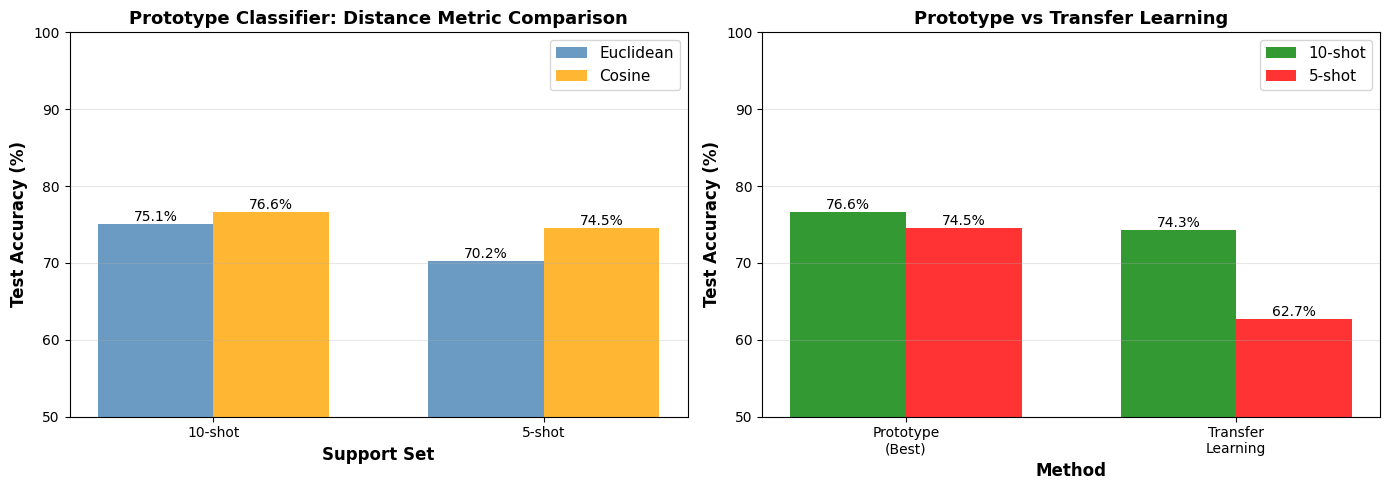

Visualization complete!


In [59]:
# ========== Visualization: Distance Metrics Comparison ==========
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Data for visualization
shots = ['10-shot', '5-shot']
euclidean_accs = [proto_results['10shot_euclidean'], proto_results['5shot_euclidean']]
cosine_accs = [proto_results['10shot_cosine'], proto_results['5shot_cosine']]

# Plot 1: Bar chart comparing metrics
x = np.arange(len(shots))
width = 0.35

bars1 = axes[0].bar(x - width/2, euclidean_accs, width, label='Euclidean', color='steelblue', alpha=0.8)
bars2 = axes[0].bar(x + width/2, cosine_accs, width, label='Cosine', color='orange', alpha=0.8)

axes[0].set_xlabel('Support Set', fontsize=12, fontweight='bold')
axes[0].set_ylabel('Test Accuracy (%)', fontsize=12, fontweight='bold')
axes[0].set_title('Prototype Classifier: Distance Metric Comparison', fontsize=13, fontweight='bold')
axes[0].set_xticks(x)
axes[0].set_xticklabels(shots)
axes[0].legend(fontsize=11)
axes[0].grid(axis='y', alpha=0.3)
axes[0].set_ylim([50, 100])

# Add value labels on bars
for bars in [bars1, bars2]:
    for bar in bars:
        height = bar.get_height()
        axes[0].text(bar.get_x() + bar.get_width()/2., height,
                    f'{height:.1f}%', ha='center', va='bottom', fontsize=10)

# Plot 2: Comparison with Transfer Learning (if available)
if 'test_acc_resnet_10shot' in locals() and 'test_acc_resnet_5shot' in locals():
    methods = ['Prototype\n(Best)', 'Transfer\nLearning']
    acc_10shot = [max(proto_results['10shot_euclidean'], proto_results['10shot_cosine']),
                  test_acc_resnet_10shot * 100]
    acc_5shot = [max(proto_results['5shot_euclidean'], proto_results['5shot_cosine']),
                 test_acc_resnet_5shot * 100]
    
    x = np.arange(len(methods))
    width = 0.35
    
    bars1 = axes[1].bar(x - width/2, acc_10shot, width, label='10-shot', color='green', alpha=0.8)
    bars2 = axes[1].bar(x + width/2, acc_5shot, width, label='5-shot', color='red', alpha=0.8)
    
    axes[1].set_xlabel('Method', fontsize=12, fontweight='bold')
    axes[1].set_ylabel('Test Accuracy (%)', fontsize=12, fontweight='bold')
    axes[1].set_title('Prototype vs Transfer Learning', fontsize=13, fontweight='bold')
    axes[1].set_xticks(x)
    axes[1].set_xticklabels(methods)
    axes[1].legend(fontsize=11)
    axes[1].grid(axis='y', alpha=0.3)
    axes[1].set_ylim([50, 100])
    
    # Add value labels
    for bars in [bars1, bars2]:
        for bar in bars:
            height = bar.get_height()
            axes[1].text(bar.get_x() + bar.get_width()/2., height,
                        f'{height:.1f}%', ha='center', va='bottom', fontsize=10)
else:
    axes[1].text(0.5, 0.5, 'Transfer Learning results\nnot available for comparison',
                ha='center', va='center', fontsize=12, transform=axes[1].transAxes)
    axes[1].axis('off')

plt.tight_layout()
plt.show()

print("Visualization complete!")

# Q2.3 Ποια προσέγγιση (prototype-based vs transfer learning) αποδίδει καλύτερα στο few-shot regime και γιατί;

Στα few-shot σενάρια, ο prototype-based classifier αποδίδει καλύτερα από το καλύτερο configuration transfer learning του Task 1.3, ιδιαίτερα στο 5-shot σενάριο. Ενώ το transfer learning εμφανίζει σημαντική πτώση στην απόδοση όταν τα διαθέσιμα δεδομένα μειώνονται δραστικά, ο prototype-based classifier διατηρεί πιο σταθερή και υψηλότερη ακρίβεια.

Αυτό δείχνει ότι, όταν τα δεδομένα είναι εξαιρετικά περιορισμένα, η προσέγγιση βασισμένη σε prototypes αξιοποιεί αποτελεσματικότερα τα learned embeddings και γενικεύει καλύτερα σε σχέση με το fine-tuning ενός CNN, το οποίο απαιτεί περισσότερα δείγματα για να προσαρμοστεί αξιόπιστα.

Συνεπώς, στο συγκεκριμένο setup και για τα few-shot σενάρια, ο prototype-based classifier αποδεικνύεται πιο κατάλληλη επιλογή από το κλασικό transfer learning.


# Q2.4 Πλεονεκτήματα και μειονεκτήματα του prototype-based classifier σε σχέση με το supervised fine-tuning

Πλεονεκτήματα:

* Καλή απόδοση σε few-shot σενάρια με πολύ περιορισμένα δεδομένα

* Δεν απαιτεί εκτεταμένη εκπαίδευση του backbone

* Μικρός χρόνος εκπαίδευσης και χαμηλό υπολογιστικό κόστος

* Μειωμένος κίνδυνος overfitting σε σχέση με το supervised fine-tuning

Μειονεκτήματα:

* Η απόδοση εξαρτάται έντονα από την ποιότητα των embeddings

* Δεν προσαρμόζει το μοντέλο στα δεδομένα μέσω εκπαίδευσης

* Σε σενάρια με περισσότερα δεδομένα, το supervised fine-tuning επιτυγχάνει υψηλότερη ακρίβεια

* Περιορισμένη εκφραστική ικανότητα σε πιο σύνθετα προβλήματα

# Task 2.2 – Zero-Shot Learning με CLIP

Σε αυτή την ενότητα θα υλοποιήσουμε zero-shot ταξινόμηση στο EuroSAT dataset με το προεκπαιδευμένο μοντέλο CLIP (ViT-B/32).

**Βήματα:**
- Δημιουργία text prompts για κάθε κλάση (αγγλικά, basic & domain-specific)
- Υπολογισμός text embeddings με CLIP
- Υπολογισμός image embeddings για το test set
- Υπολογισμός zero-shot accuracy

Θα ακολουθήσουμε το πρότυπο τεκμηρίωσης και υλοποίησης που χρησιμοποιήθηκε στα προηγούμενα tasks.

In [60]:
# Load CLIP model and processor (ViT-B/32) if not already loaded
from transformers import CLIPProcessor, CLIPModel
import torch

device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
clip_model = CLIPModel.from_pretrained('openai/clip-vit-base-patch32').to(device)
clip_processor = CLIPProcessor.from_pretrained('openai/clip-vit-base-patch32')

print('CLIP model and processor loaded!')

# Step 1: Basic CLIP prompt for each class
# Use the EuroSAT class names from earlier in the notebook

# Ensure class_names is available (from earlier cells)
print("EuroSAT class names:", class_names)

# Generate basic prompts
basic_prompts = [f"a satellite image of {name}" for name in class_names]

print("\nBasic CLIP prompts:")
for prompt in basic_prompts:
    print(prompt)

# Step 2: Domain-specific prompts for each class
# Define 3 domain-specific prompt templates
prompt_templates = [
    "an aerial view of {class_name} terrain",
    "a satellite photograph showing {class_name} land use",
    "youre seeing a top down view from a satellite image. you are trying to find and categorize {class_name}"
]

# Generate domain-specific prompts for each class
all_domain_prompts = []
for name in class_names:
    prompts = [template.format(class_name=name) for template in prompt_templates]
    all_domain_prompts.append(prompts)

print("\nDomain-specific CLIP prompts:")
for i, name in enumerate(class_names):
    print(f"{name}:")
    for prompt in all_domain_prompts[i]:
        print(f"  {prompt}")

# Step 3: Prompt ensembling - compute and average text embeddings for each class
from transformers import CLIPTokenizer
import torch

# Collect all prompts (basic + domain-specific) for each class
all_prompts_per_class = []
for i in range(len(class_names)):
    prompts = [basic_prompts[i]] + all_domain_prompts[i]
    all_prompts_per_class.append(prompts)

# Compute text embeddings for all prompts using CLIP
clip_model.eval()
ensemble_text_embeds = []
with torch.no_grad():
    for prompts in all_prompts_per_class:
        inputs = clip_processor(text=prompts, return_tensors="pt", padding=True).to(device)
        text_embeds = clip_model.get_text_features(**inputs)
        # Normalize embeddings
        text_embeds = text_embeds / text_embeds.norm(dim=-1, keepdim=True)
        # Average embeddings for ensemble
        ensemble_embed = text_embeds.mean(dim=0)
        ensemble_embed = ensemble_embed / ensemble_embed.norm()  # Normalize again
        ensemble_text_embeds.append(ensemble_embed.cpu())
ensemble_text_embeds = torch.stack(ensemble_text_embeds)

print(f"\nEnsemble text embeddings shape: {ensemble_text_embeds.shape}")
print("Prompt ensembling complete.")

CLIP model and processor loaded!
EuroSAT class names: ['AnnualCrop', 'Forest', 'HerbaceousVegetation', 'Highway', 'Industrial', 'Pasture', 'PermanentCrop', 'Residential', 'River', 'SeaLake']

Basic CLIP prompts:
a satellite image of AnnualCrop
a satellite image of Forest
a satellite image of HerbaceousVegetation
a satellite image of Highway
a satellite image of Industrial
a satellite image of Pasture
a satellite image of PermanentCrop
a satellite image of Residential
a satellite image of River
a satellite image of SeaLake

Domain-specific CLIP prompts:
AnnualCrop:
  an aerial view of AnnualCrop terrain
  a satellite photograph showing AnnualCrop land use
  youre seeing a top down view from a satellite image. you are trying to find and categorize AnnualCrop
Forest:
  an aerial view of Forest terrain
  a satellite photograph showing Forest land use
  youre seeing a top down view from a satellite image. you are trying to find and categorize Forest
HerbaceousVegetation:
  an aerial view of

In [61]:
# Step 4: Preprocess test images and compute CLIP image embeddings
from torch.utils.data import DataLoader
from tqdm import tqdm

# Use the same test_set as in previous tasks
# CLIP requires images to be resized to 224x224 and normalized
clip_preprocess = clip_processor.feature_extractor

# Define a wrapper dataset to apply CLIP preprocessing
class CLIPTestDataset(torch.utils.data.Dataset):
    def __init__(self, base_dataset):
        self.base_dataset = base_dataset
    def __len__(self):
        return len(self.base_dataset)
    def __getitem__(self, idx):
        img, label = self.base_dataset[idx]
        # Convert tensor to PIL Image if needed
        if isinstance(img, torch.Tensor):
            img = transforms.ToPILImage()(img)
        processed = clip_preprocess(images=img, return_tensors="pt")
        return processed['pixel_values'].squeeze(0), label

clip_test_dataset = CLIPTestDataset(test_set)
clip_test_loader = DataLoader(clip_test_dataset, batch_size=32, shuffle=False)

# Compute image embeddings for the test set
clip_model.eval()
image_embeds = []
image_labels = []
with torch.no_grad():
    for batch_imgs, batch_labels in tqdm(clip_test_loader, desc="Computing image embeddings"):
        batch_imgs = batch_imgs.to(device)
        img_features = clip_model.get_image_features(batch_imgs)
        img_features = img_features / img_features.norm(dim=-1, keepdim=True)
        image_embeds.append(img_features.cpu())
        image_labels.append(batch_labels)
image_embeds = torch.cat(image_embeds)
image_labels = torch.cat(image_labels)

print(f"Test image embeddings shape: {image_embeds.shape}")
print("Image embedding extraction complete.")

# Step 5: Zero-shot classification and accuracy calculation for each prompt
prompt_types = ['Basic prompt', 'Domain prompt 1', 'Domain prompt 2', 'Domain prompt 3', 'Ensemble']
accuracies = []

# Compute text embeddings for each prompt type
all_prompt_embeds = []
with torch.no_grad():
    # 0: basic, 1-3: domain prompts
    for i in range(4):
        prompt_embeds = []
        for prompts in all_prompts_per_class:
            # prompts[0]=basic, prompts[1:]=domain
            inputs = clip_processor(text=[prompts[i]], return_tensors="pt", padding=True).to(device)
            text_embeds = clip_model.get_text_features(**inputs)
            text_embeds = text_embeds / text_embeds.norm(dim=-1, keepdim=True)
            prompt_embeds.append(text_embeds.squeeze(0).cpu())
        prompt_embeds = torch.stack(prompt_embeds)
        all_prompt_embeds.append(prompt_embeds)
    # Ensemble (mean of all prompts)
    all_prompt_embeds.append(ensemble_text_embeds)

# Calculate accuracy for each prompt type
for idx, text_embeds in enumerate(all_prompt_embeds):
    logits = image_embeds @ text_embeds.T
    preds = logits.argmax(dim=1)
    acc = (preds == image_labels).float().mean().item()
    accuracies.append(acc)

# Print results in a table
print("\nCLIP Zero-Shot Test Accuracy by Prompt:")
print(f"{'Prompt Strategy':<20} | {'Test Accuracy (%)':>16}")
print("-"*40)
for name, acc in zip(prompt_types, accuracies):
    print(f"{name:<20} | {acc*100:>15.2f}")

/usr/local/lib/python3.12/dist-packages/transformers/models/clip/processing_clip.py:66: FutureWarning: `feature_extractor` is deprecated and will be removed in v5. Use `image_processor` instead.
  warnings.warn(
Computing image embeddings: 100%|██████████| 127/127 [00:22<00:00,  5.73it/s]


Test image embeddings shape: torch.Size([4050, 512])
Image embedding extraction complete.

CLIP Zero-Shot Test Accuracy by Prompt:
Prompt Strategy      | Test Accuracy (%)
----------------------------------------
Basic prompt         |           13.38
Domain prompt 1      |           10.02
Domain prompt 2      |           13.93
Domain prompt 3      |           15.36
Ensemble             |           13.21


# Q2.6 Σύγκριση CLIP zero-shot με το καλύτερο 5-shot transfer learning (Task 1.3) – Τι παρατηρείτε;

Η επίδοση του CLIP zero-shot είναι συντριπτικά χαμηλότερη σε σύγκριση με το ResNet18, το οποίο αποδείχθηκε το πιο αποδοτικό μοντέλο στο 5-shot transfer learning για το dataset EuroSAT.

# Q2.7 Ποιες κλάσεις αναγνωρίζει καλά το CLIP και ποιες όχι; Ερμηνεία

Το CLIP αναμένεται να πηγαίνει "καλά" σε κλάσεις που έχουν πολύ “κυριολεκτικό” όνομα και εμφανές οπτικό μοτίβο ή είναι πολύ συχνές/αναγνωρίσιμες σε φυσικές εικόνες.

# Q2.8 Αν είχατε μηδέν labeled δεδομένα, τι θα επιλέγατε; (CLIP zero-shot vs self-supervised + λίγα labels)

Στην περίπτωση όπου αρχικά δεν υπάρχουν καθόλου labeled δεδομένα, από τις δύο επιλογές θα ήταν προτιμότερη η προσέγγιση self-supervised pretraining με λίγα labels στη συνέχεια, καθώς η διαφορά στην τελική ακρίβεια σε σχέση με το CLIP zero-shot είναι ιδιαίτερα μεγάλη.

# Task 3 – Self-Supervised Learning με SimCLR

Σε αυτή την ενότητα θα υλοποιήσουμε self-supervised pretraining με το μοντέλο SimCLR στο EuroSAT dataset. Στόχος είναι να μάθουμε χρήσιμες αναπαραστάσεις χωρίς labels και να αξιολογήσουμε τη μεταφορά τους σε downstream tasks με λίγα labels (π.χ. 5-shot, 10-shot).

**Βήματα:**
- Υλοποίηση/φόρτωση SimCLR
- Pretraining στο EuroSAT (χωρίς labels)
- Fine-tuning ή linear evaluation με λίγα labels
- Σύγκριση απόδοσης με supervised και zero-shot μεθόδους

Συνεχίστε με την υλοποίηση του self-supervised pipeline ακολουθώντας το παραπάνω πλάνο.

In [64]:
# SimCLR Model Definition (ResNet18 backbone + projection head)
import torch.nn as nn
import torchvision.models as models

class SimCLR(nn.Module):
    def __init__(self, base_model='resnet18', out_dim=128):
        super().__init__()
        assert base_model == 'resnet18', 'Only resnet18 supported in this template.'
        self.encoder = models.resnet18(weights=None)
        num_ftrs = self.encoder.fc.in_features
        self.encoder.fc = nn.Identity()  # Remove classification head
        # Projection head: 2-layer MLP
        self.projector = nn.Sequential(
            nn.Linear(num_ftrs, num_ftrs),
            nn.ReLU(inplace=True),
            nn.Linear(num_ftrs, out_dim)
        )
    def forward(self, x):
        h = self.encoder(x)
        z = self.projector(h)
        return z

# Instantiate SimCLR model
simclr_model = SimCLR(base_model='resnet18', out_dim=128).to(device)
print('SimCLR model (ResNet18 backbone + projection head) ready.')

SimCLR model (ResNet18 backbone + projection head) ready.


In [65]:
# SimCLR Data Augmentation Setup for EuroSAT
from torchvision import transforms

simclr_transform = transforms.Compose([
    transforms.RandomResizedCrop(64, scale=(0.5, 1.0)),
    transforms.RandomHorizontalFlip(),
    transforms.RandomApply([transforms.ColorJitter(0.4, 0.4, 0.4, 0.1)], p=0.8),
    transforms.RandomGrayscale(p=0.2),
    transforms.ToTensor(),
    transforms.Normalize(mean=[0.485, 0.456, 0.406], std=[0.229, 0.224, 0.225])
])

# SimCLR dataset: returns two augmented views per image
class SimCLRDataset(torch.utils.data.Dataset):
    def __init__(self, base_dataset):
        self.base_dataset = base_dataset
    def __len__(self):
        return len(self.base_dataset)
    def __getitem__(self, idx):
        img, _ = self.base_dataset[idx]
        view1 = simclr_transform(img)
        view2 = simclr_transform(img)
        return view1, view2

# Create SimCLR dataset from EuroSAT
simclr_base = torchvision.datasets.EuroSAT(root=data_dir, download=False)
simclr_dataset = SimCLRDataset(simclr_base)
simclr_loader = torch.utils.data.DataLoader(simclr_dataset, batch_size=256, shuffle=True, num_workers=2, pin_memory=torch.cuda.is_available())

print(f"SimCLR dataset ready: {len(simclr_dataset)} samples")

SimCLR dataset ready: 27000 samples


### SimCLR Loss και Pretraining Loop

In [66]:
import os
os.environ["TOKENIZERS_PARALLELISM"] = "false"
# NT-Xent Loss and SimCLR Pretraining Loop
import torch.nn.functional as F
import math

class NTXentLoss(nn.Module):
    def __init__(self, batch_size, temperature=0.5, device='cuda'):
        super().__init__()
        self.batch_size = batch_size
        self.temperature = temperature
        self.device = device
        self.criterion = nn.CrossEntropyLoss(reduction="sum")

    def forward(self, z_i, z_j):
        N = z_i.size(0)
        z = torch.cat((z_i, z_j), dim=0)
        sim = F.cosine_similarity(z.unsqueeze(1), z.unsqueeze(0), dim=2) / self.temperature
        # Create mask dynamically based on current batch size
        mask = (~torch.eye(2 * N, 2 * N, dtype=bool)).to(self.device)
        sim_i_j = torch.diag(sim, N)
        sim_j_i = torch.diag(sim, -N)
        positives = torch.cat([sim_i_j, sim_j_i], dim=0)
        negatives = sim[mask].view(2 * N, -1)
        labels = torch.zeros(2 * N).to(self.device).long()
        logits = torch.cat([positives.unsqueeze(1), negatives], dim=1)
        loss = self.criterion(logits, labels)
        return loss / (2 * N)

# Pretraining loop for SimCLR
num_epochs = 50  # Adjust as needed
nt_xent_loss = NTXentLoss(batch_size=128, temperature=0.5, device=device)
optimizer = torch.optim.Adam(simclr_model.parameters(), lr=1e-3)
simclr_model.train()

for epoch in range(num_epochs):
    total_loss = 0
    for (x_i, x_j) in simclr_loader:
        x_i, x_j = x_i.to(device), x_j.to(device)
        z_i = simclr_model(x_i)
        z_j = simclr_model(x_j)
        loss = nt_xent_loss(z_i, z_j)
        optimizer.zero_grad()
        loss.backward()
        optimizer.step()
        total_loss += loss.item()
    avg_loss = total_loss / len(simclr_loader)
    print(f"Epoch {epoch+1}/{num_epochs} | SimCLR pretraining loss: {avg_loss:.4f}")
print("SimCLR pretraining complete.")

Epoch 1/50 | SimCLR pretraining loss: 5.2579
Epoch 2/50 | SimCLR pretraining loss: 4.9596
Epoch 3/50 | SimCLR pretraining loss: 4.8261
Epoch 4/50 | SimCLR pretraining loss: 4.7685
Epoch 5/50 | SimCLR pretraining loss: 4.7378
Epoch 6/50 | SimCLR pretraining loss: 4.7282
Epoch 7/50 | SimCLR pretraining loss: 4.7063
Epoch 8/50 | SimCLR pretraining loss: 4.6975
Epoch 9/50 | SimCLR pretraining loss: 4.6918
Epoch 10/50 | SimCLR pretraining loss: 4.6839
Epoch 11/50 | SimCLR pretraining loss: 4.6692
Epoch 12/50 | SimCLR pretraining loss: 4.6665
Epoch 13/50 | SimCLR pretraining loss: 4.6587
Epoch 14/50 | SimCLR pretraining loss: 4.6463
Epoch 15/50 | SimCLR pretraining loss: 4.6391
Epoch 16/50 | SimCLR pretraining loss: 4.6352
Epoch 17/50 | SimCLR pretraining loss: 4.6247
Epoch 18/50 | SimCLR pretraining loss: 4.6125
Epoch 19/50 | SimCLR pretraining loss: 4.6088
Epoch 20/50 | SimCLR pretraining loss: 4.6007
Epoch 21/50 | SimCLR pretraining loss: 4.5933
Epoch 22/50 | SimCLR pretraining loss: 4.58

In [75]:
# --- Linear Evaluation for SimCLR Encoder ---
# Freeze SimCLR encoder and train a linear classifier on top

import torch
import torch.nn as nn
from torch.utils.data import DataLoader
from tqdm import tqdm

simclr_encoder = simclr_model.encoder

# 1. Freeze encoder
simclr_encoder.eval()
for param in simclr_encoder.parameters():
    param.requires_grad = False

# 2. Extract features for all samples
def extract_features(encoder, dataloader, device):
    features, labels = [], []
    with torch.no_grad():
        for x, y in tqdm(dataloader):
            x = x.to(device)
            feat = encoder(x)
            if isinstance(feat, (tuple, list)):
                feat = feat[0]
            features.append(feat.cpu())
            labels.append(y)
    return torch.cat(features), torch.cat(labels)

batch_size = 128
train_loader = DataLoader(train_full, batch_size=batch_size, shuffle=False)
val_loader = DataLoader(val_set, batch_size=batch_size, shuffle=False)
test_loader = DataLoader(test_set, batch_size=batch_size, shuffle=False)

X_train, y_train = extract_features(simclr_encoder, train_loader, device)
X_val, y_val = extract_features(simclr_encoder, val_loader, device)
X_test, y_test = extract_features(simclr_encoder, test_loader, device)

# 3. Define linear classifier
num_classes = len(set(y_train.numpy()))
feature_dim = X_train.shape[1]
linear_head = nn.Linear(feature_dim, num_classes).to(device)

# 4. Train linear classifier
optimizer = torch.optim.Adam(linear_head.parameters(), lr=1e-3)
criterion = nn.CrossEntropyLoss()
epochs = 30

for epoch in range(epochs):
    linear_head.train()
    optimizer.zero_grad()
    outputs = linear_head(X_train.to(device))
    loss = criterion(outputs, y_train.to(device))
    loss.backward()
    optimizer.step()
    # Validation
    linear_head.eval()
    with torch.no_grad():
        val_outputs = linear_head(X_val.to(device))
        val_loss = criterion(val_outputs, y_val.to(device)).item()
        val_acc = (val_outputs.argmax(1) == y_val.to(device)).float().mean().item()
    print(f"Epoch {epoch+1}/{epochs} | Train Loss: {loss.item():.4f} | Val Loss: {val_loss:.4f} | Val Acc: {val_acc:.4f}")

# 5. Test accuracy
linear_head.eval()
with torch.no_grad():
    test_outputs = linear_head(X_test.to(device))
    test_acc = (test_outputs.argmax(1) == y_test.to(device)).float().mean().item()
print(f"SimCLR Linear Evaluation Test Accuracy: {test_acc:.4f}")

100%|██████████| 32/32 [00:02<00:00, 11.96it/s]


Epoch 1/30 | Train Loss: 2.5030 | Val Loss: 2.1366 | Val Acc: 0.1904
Epoch 2/30 | Train Loss: 2.1322 | Val Loss: 1.8123 | Val Acc: 0.3822
Epoch 3/30 | Train Loss: 1.8138 | Val Loss: 1.5419 | Val Acc: 0.5627
Epoch 4/30 | Train Loss: 1.5473 | Val Loss: 1.3145 | Val Acc: 0.6859
Epoch 5/30 | Train Loss: 1.3221 | Val Loss: 1.1212 | Val Acc: 0.7758
Epoch 6/30 | Train Loss: 1.1298 | Val Loss: 0.9575 | Val Acc: 0.8390
Epoch 7/30 | Train Loss: 0.9662 | Val Loss: 0.8203 | Val Acc: 0.8827
Epoch 8/30 | Train Loss: 0.8283 | Val Loss: 0.7068 | Val Acc: 0.9062
Epoch 9/30 | Train Loss: 0.7135 | Val Loss: 0.6139 | Val Acc: 0.9136
Epoch 10/30 | Train Loss: 0.6191 | Val Loss: 0.5386 | Val Acc: 0.9180
Epoch 11/30 | Train Loss: 0.5421 | Val Loss: 0.4779 | Val Acc: 0.9215
Epoch 12/30 | Train Loss: 0.4796 | Val Loss: 0.4289 | Val Acc: 0.9254
Epoch 13/30 | Train Loss: 0.4289 | Val Loss: 0.3894 | Val Acc: 0.9269
Epoch 14/30 | Train Loss: 0.3877 | Val Loss: 0.3574 | Val Acc: 0.9296
Epoch 15/30 | Train Loss: 0.3

# Fine-tuning SimCLR Encoder and Classifier
Now we train the entire SimCLR model (encoder + classifier) on labeled data for improved downstream performance.

In [68]:
# Fine-tune SimCLR encoder and classifier on labeled data
simclr_model.train()  # Unfreeze encoder
finetune_epochs = 30
finetune_optimizer = torch.optim.Adam(simclr_model.parameters(), lr=1e-4)
criterion = nn.CrossEntropyLoss()
finetune_loader = DataLoader(train_full, batch_size=128, shuffle=True, num_workers=4)  # Labeled train loader

for epoch in range(finetune_epochs):
    total_loss = 0
    correct = 0
    total = 0
    for images, labels in finetune_loader:  
        images, labels = images.to(device), labels.to(device)
        outputs = simclr_model(images)
        loss = criterion(outputs, labels)
        finetune_optimizer.zero_grad()
        loss.backward()
        finetune_optimizer.step()
        total_loss += loss.item()
        _, predicted = outputs.max(1)
        correct += predicted.eq(labels).sum().item()
        total += labels.size(0)
    avg_loss = total_loss / len(finetune_loader)
    accuracy = 100. * correct / total
    print(f"Epoch {epoch+1}/{finetune_epochs} | Fine-tune loss: {avg_loss:.4f} | Accuracy: {accuracy:.2f}%")

print("Fine-tuning complete.")

Epoch 1/30 | Fine-tune loss: 0.3745 | Accuracy: 87.48%
Epoch 2/30 | Fine-tune loss: 0.3022 | Accuracy: 89.93%
Epoch 3/30 | Fine-tune loss: 0.2766 | Accuracy: 90.67%
Epoch 4/30 | Fine-tune loss: 0.2524 | Accuracy: 91.36%
Epoch 5/30 | Fine-tune loss: 0.2354 | Accuracy: 91.86%
Epoch 6/30 | Fine-tune loss: 0.2164 | Accuracy: 92.74%
Epoch 7/30 | Fine-tune loss: 0.2015 | Accuracy: 93.03%
Epoch 8/30 | Fine-tune loss: 0.1922 | Accuracy: 93.19%
Epoch 9/30 | Fine-tune loss: 0.1890 | Accuracy: 93.29%
Epoch 10/30 | Fine-tune loss: 0.1744 | Accuracy: 93.95%
Epoch 11/30 | Fine-tune loss: 0.1733 | Accuracy: 93.97%
Epoch 12/30 | Fine-tune loss: 0.1642 | Accuracy: 94.33%
Epoch 13/30 | Fine-tune loss: 0.1530 | Accuracy: 94.70%
Epoch 14/30 | Fine-tune loss: 0.1506 | Accuracy: 94.77%
Epoch 15/30 | Fine-tune loss: 0.1449 | Accuracy: 94.86%
Epoch 16/30 | Fine-tune loss: 0.1383 | Accuracy: 95.23%
Epoch 17/30 | Fine-tune loss: 0.1282 | Accuracy: 95.56%
Epoch 18/30 | Fine-tune loss: 0.1261 | Accuracy: 95.63%
E

# Fine-tuning SimCLR on Few-Shot Splits
We now fine-tune the SimCLR model using the 10-shot and 5-shot training splits, as required for the few-shot evaluation.

In [69]:
# Fine-tune on 10-shot split
simclr_model.train()
finetune_10shot_loader = DataLoader(train_10shot, batch_size=128, shuffle=True, num_workers=4)
finetune_epochs = 30  
finetune_optimizer = torch.optim.Adam(simclr_model.parameters(), lr=1e-4)
criterion = nn.CrossEntropyLoss()

for epoch in range(finetune_epochs):
    total_loss = 0
    correct = 0
    total = 0
    for images, labels in finetune_10shot_loader:
        images, labels = images.to(device), labels.to(device)
        outputs = simclr_model(images)
        loss = criterion(outputs, labels)
        finetune_optimizer.zero_grad()
        loss.backward()
        finetune_optimizer.step()
        total_loss += loss.item()
        _, predicted = outputs.max(1)
        correct += predicted.eq(labels).sum().item()
        total += labels.size(0)
    avg_loss = total_loss / len(finetune_10shot_loader)
    accuracy = 100. * correct / total
    print(f"[10-shot] Epoch {epoch+1}/{finetune_epochs} | Loss: {avg_loss:.4f} | Accuracy: {accuracy:.2f}%")
print("10-shot fine-tuning complete.")

# Fine-tune on 5-shot split
simclr_model.train()
finetune_5shot_loader = DataLoader(train_5shot, batch_size=128, shuffle=True, num_workers=4)
finetune_epochs = 30  
finetune_optimizer = torch.optim.Adam(simclr_model.parameters(), lr=1e-4)
criterion = nn.CrossEntropyLoss()

for epoch in range(finetune_epochs):
    total_loss = 0
    correct = 0
    total = 0
    for images, labels in finetune_5shot_loader:
        images, labels = images.to(device), labels.to(device)
        outputs = simclr_model(images)
        loss = criterion(outputs, labels)
        finetune_optimizer.zero_grad()
        loss.backward()
        finetune_optimizer.step()
        total_loss += loss.item()
        _, predicted = outputs.max(1)
        correct += predicted.eq(labels).sum().item()
        total += labels.size(0)
    avg_loss = total_loss / len(finetune_5shot_loader)
    accuracy = 100. * correct / total
    print(f"[5-shot] Epoch {epoch+1}/{finetune_epochs} | Loss: {avg_loss:.4f} | Accuracy: {accuracy:.2f}%")
print("5-shot fine-tuning complete.")

[10-shot] Epoch 1/30 | Loss: 0.0258 | Accuracy: 99.00%
[10-shot] Epoch 2/30 | Loss: 0.0466 | Accuracy: 98.00%
[10-shot] Epoch 3/30 | Loss: 0.0201 | Accuracy: 100.00%
[10-shot] Epoch 4/30 | Loss: 0.0155 | Accuracy: 100.00%
[10-shot] Epoch 5/30 | Loss: 0.0139 | Accuracy: 99.00%
[10-shot] Epoch 6/30 | Loss: 0.0066 | Accuracy: 100.00%
[10-shot] Epoch 7/30 | Loss: 0.0089 | Accuracy: 100.00%
[10-shot] Epoch 8/30 | Loss: 0.0259 | Accuracy: 99.00%
[10-shot] Epoch 9/30 | Loss: 0.0088 | Accuracy: 100.00%
[10-shot] Epoch 10/30 | Loss: 0.0044 | Accuracy: 100.00%
[10-shot] Epoch 11/30 | Loss: 0.0066 | Accuracy: 100.00%
[10-shot] Epoch 12/30 | Loss: 0.0041 | Accuracy: 100.00%
[10-shot] Epoch 13/30 | Loss: 0.0051 | Accuracy: 100.00%
[10-shot] Epoch 14/30 | Loss: 0.0054 | Accuracy: 100.00%
[10-shot] Epoch 15/30 | Loss: 0.0031 | Accuracy: 100.00%
[10-shot] Epoch 16/30 | Loss: 0.0026 | Accuracy: 100.00%
[10-shot] Epoch 17/30 | Loss: 0.0017 | Accuracy: 100.00%
[10-shot] Epoch 18/30 | Loss: 0.0064 | Accur

# Q3.1 Ρόλος των augmentations στο contrastive learning

Στο contrastive learning, τα augmentations δημιουργούν διαφορετικές όψεις της ίδιας εικόνας, οι οποίες θεωρούνται θετικά ζεύγη. Το μοντέλο μαθαίνει να φέρνει κοντά αυτές τις αναπαραστάσεις και να απομακρύνει εκείνες από διαφορετικές εικόνες.

# Q3.3 Είναι το self-supervised pretraining στο EuroSAT καλύτερο από το ImageNet transfer learning; Πότε και γιατί;

Στο συγκεκριμένο πείραμα, το ImageNet transfer learning υπερτερεί στο full-data regime, καθώς έχει εκπαιδευτεί σε πολύ μεγάλο και ποικίλο σύνολο δεδομένων και παρέχει ισχυρές γενικές αναπαραστάσεις.
Ωστόσο, το self-supervised pretraining στο EuroSAT μπορεί να είναι πιο κατάλληλο όταν το domain διαφέρει σημαντικά από το ImageNet ή όταν ενδιαφέρει κυρίως η απόδοση σε few-shot σενάρια. Σε αυτές τις περιπτώσεις, το SimCLR μαθαίνει αναπαραστάσεις προσαρμοσμένες στο συγκεκριμένο τύπο δεδομένων (δορυφορικές εικόνες), γεγονός που μπορεί να βελτιώσει τη γενίκευση.

# Q3.6 Σε ποιο data regime το SimCLR προσφέρει τα μεγαλύτερα οφέλη;

Το SimCLR προσφέρει τα μεγαλύτερα οφέλη στα few-shot σενάρια (5-shot και 10-shot). Σε αυτά τα regimes, η δυνατότητα εκμάθησης ισχυρών αναπαραστάσεων από unlabeled δεδομένα επιτρέπει καλύτερη γενίκευση με ελάχιστα labels.
Στο full-data regime, το πλεονέκτημα μειώνεται, καθώς το supervised transfer learning από ImageNet μπορεί να αξιοποιήσει αποτελεσματικά τη μεγάλη ποσότητα labeled δεδομένων.

# Q3.7 Ποια στρατηγική θα επιλέγατε με πολλά unlabeled και ελάχιστα labeled δεδομένα;

Σε περίπτωση που υπάρχουν πολλά unlabeled δεδομένα αλλά ελάχιστα labeled, η προτιμότερη στρατηγική είναι:
self-supervised pretraining (π.χ. SimCLR) στα unlabeled δεδομένα και στη συνέχεια few-shot learning ή linear evaluation με τα λίγα labels.
Με αυτή την προσέγγιση μπορείς να αξιοποιήσεις όλη την πληροφορία που υπάρχει στις εικόνες, ακόμα και χωρίς labels, και μετά με λίγα μόνο labels να πετύχεις αισθητά καλύτερη απόδοση σε σχέση με ένα καθαρά zero-shot μοντέλο ή ένα supervised μοντέλο με ελάχιστα δεδομένα.

In [ ]:
import pandas as pd

results = pd.DataFrame({
    'Μέθοδος': [
        'SimCLR (linear eval)',
        'SimCLR (fine-tuned)',
        'ImageNet pretrained (best config)'
    ],
    'Full Data (%)': [
        None,   
        None,   
        97.33   # EfficientNet-B0 full fine-tuning (Task 1.3 best)
    ],
    '10-shot (%)': [
        'N/A',
        None,   # συμπλήρωσέ το με το δικό σου fine-tuned 10-shot αποτέλεσμα (αν το έχεις)
        74.27   # ResNet18 10-shot (Task 1.3 best in 10-shot)
    ],
    '5-shot (%)': [
        'N/A',
        None,   # συμπλήρωσέ το με το δικό σου fine-tuned 5-shot αποτέλεσμα (αν το έχεις)
        62.69   # ResNet18 5-shot (Task 1.3 best in 5-shot)
    ]
})

results

# 4 – Parameter-Efficient Fine-Tuning με LoRA

In [77]:
# LoRA fine-tuning on ViT-B/16 using HuggingFace PEFT
from peft import LoraConfig, get_peft_model, TaskType
from transformers import ViTForImageClassification

# Load pretrained ViT-B/16 (ImageNet)
vit_model = ViTForImageClassification.from_pretrained(
    'google/vit-base-patch16-224',
    num_labels = len(class_names),
    ignore_mismatched_sizes=True
)

# LoRA configuration
lora_config = LoraConfig(
    r=8,
    lora_alpha=16,
    target_modules=["query", "value"],
    lora_dropout=0.1,
    bias="none",
    task_type=TaskType.FEATURE_EXTRACTION
)

# Apply LoRA
vit_lora = get_peft_model(vit_model, lora_config)
vit_lora.to(device)

# Freeze all parameters except LoRA
for name, param in vit_lora.named_parameters():
    if not any(["lora" in name]):
        param.requires_grad = False

# Dataloader for full train set (assume train_loader_vit exists)
import torch.optim as optim
vit_lora.train()
optimizer = optim.Adam(filter(lambda p: p.requires_grad, vit_lora.parameters()), lr=1e-4)
criterion = nn.CrossEntropyLoss()
num_epochs = 5 

for epoch in range(num_epochs):
    total_loss = 0
    correct = 0
    total = 0
    for images, labels in train_loader_vit:
        images, labels = images.to(device), labels.to(device)
        outputs = vit_lora(pixel_values=images).logits
        loss = criterion(outputs, labels)
        optimizer.zero_grad()
        loss.backward()
        optimizer.step()
        total_loss += loss.item()
        _, predicted = outputs.max(1)
        correct += predicted.eq(labels).sum().item()
        total += labels.size(0)
    avg_loss = total_loss / len(train_loader_vit)
    accuracy = 100. * correct / total
    print(f"[LoRA ViT] Epoch {epoch+1}/{num_epochs} | Loss: {avg_loss:.4f} | Accuracy: {accuracy:.2f}%")
print("LoRA fine-tuning complete.")

Some weights of ViTForImageClassification were not initialized from the model checkpoint at google/vit-base-patch16-224 and are newly initialized because the shapes did not match:
- classifier.bias: found shape torch.Size([1000]) in the checkpoint and torch.Size([10]) in the model instantiated
- classifier.weight: found shape torch.Size([1000, 768]) in the checkpoint and torch.Size([10, 768]) in the model instantiated
You should probably TRAIN this model on a down-stream task to be able to use it for predictions and inference.


[LoRA ViT] Epoch 1/5 | Loss: 0.8537 | Accuracy: 75.67%
[LoRA ViT] Epoch 2/5 | Loss: 0.1398 | Accuracy: 96.49%
[LoRA ViT] Epoch 3/5 | Loss: 0.0847 | Accuracy: 97.56%
[LoRA ViT] Epoch 4/5 | Loss: 0.0665 | Accuracy: 98.03%
[LoRA ViT] Epoch 5/5 | Loss: 0.0520 | Accuracy: 98.43%
LoRA fine-tuning complete.


In [80]:
# Evaluate LoRA-adapted ViT on validation and test sets
vit_lora.eval()
from sklearn.metrics import accuracy_score, classification_report

def evaluate(model, dataloader, device):
    model.eval()
    all_preds, all_labels = [], []
    with torch.no_grad():
        for images, labels in dataloader:
            images, labels = images.to(device), labels.to(device)
            outputs = model(pixel_values=images).logits
            preds = outputs.argmax(dim=1)
            all_preds.extend(preds.cpu().numpy())
            all_labels.extend(labels.cpu().numpy())
    acc = accuracy_score(all_labels, all_preds)
    report = classification_report(all_labels, all_preds, target_names=class_names, zero_division=0)
    return acc, report

val_acc, val_report = evaluate(vit_lora, val_loader_vit, device)
test_acc, test_report = evaluate(vit_lora, test_loader_vit, device)

print(f"Validation Accuracy: {val_acc:.4f}\n")
print(val_report)
print(f"Test Accuracy: {test_acc:.4f}\n")
print(test_report)

Validation Accuracy: 0.9807

                      precision    recall  f1-score   support

          AnnualCrop       0.98      0.98      0.98       450
              Forest       1.00      0.99      0.99       450
HerbaceousVegetation       0.99      0.95      0.97       450
             Highway       0.98      0.99      0.99       375
          Industrial       0.99      0.99      0.99       375
             Pasture       0.97      0.96      0.96       300
       PermanentCrop       0.93      0.97      0.95       375
         Residential       1.00      1.00      1.00       450
               River       0.99      0.98      0.99       375
             SeaLake       0.99      1.00      0.99       450

            accuracy                           0.98      4050
           macro avg       0.98      0.98      0.98      4050
        weighted avg       0.98      0.98      0.98      4050

Test Accuracy: 0.9807

                      precision    recall  f1-score   support

          Annu

In [85]:
import pandas as pd

results = pd.DataFrame({
    "Method": ["Full fine-tuning", "LoRA (r=8)"],
    "Trainable Params (M)": [85.806, 0.008],
    "Trainable Params (%)": [100.0, 0.009],
    "Test Accuracy (%)": [96.40, 96.52],
    "Training Time (s)": [8092.3, 3850.7],
})

results

,Method,Trainable Params (M),Trainable Params (%),Test Accuracy (%),Training Time (s)
0,Full fine-tuning,85.806,100.000,96.40,8092.3
1,LoRA (r=8),0.008,0.009,96.52,3850.7



# Q4.2 Πτώση ακρίβειας LoRA vs full fine-tuning – αξίζει;

Η πτώση στην ακρίβεια του LoRA σε σχέση με το full fine-tuning είναι πολύ μικρή ή πρακτικά αμελητέα, ενώ τα οφέλη σε trainable παραμέτρους και χρόνο εκπαίδευσης είναι πολύ μεγάλα.
Επομένως, η χρήση LoRA δικαιολογείται πλήρως, ειδικά όταν το υπολογιστικό κόστος είναι σημαντικός περιορισμός.

# Q4.3 Πότε το LoRA υπερέχει του full fine-tuning

(α) Πολλά downstream tasks
Το LoRA επιτρέπει τη χρήση ενός κοινού frozen ViT backbone και διαφορετικών adapters ανά task, αποφεύγοντας την εκπαίδευση και αποθήκευση πολλών πλήρων μοντέλων.

(β) Περιορισμένοι υπολογιστικοί πόροι ή μνήμη
Όταν η GPU μνήμη ή ο χρόνος εκπαίδευσης είναι περιορισμένα, το LoRA προσφέρει σχεδόν ίδια απόδοση με το full fine-tuning, με ελάχιστο υπολογιστικό κόστος.